In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import scipy.optimize
from scipy.linalg import cholesky
from numpy.linalg import inv
from numpy.linalg import pinv

from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit

import statistics

import random

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

print(uproot.__version__)
print(pd.__version__)

3.14.4
2.2.2


In [2]:
def get_bin_centers(x):
    centers = []
    for i in range(len(x)-1): centers.append( x[i] + (x[i+1]-x[i])/2 )
    return centers

def get_x_err_Enu(x, x_bins):
    x_err = np.zeros_like([x,x])
    for i in range(len(x)):
            x_err[0][i] = x[i] - x_bins[i]
            x_err[1][i] = x_bins[i+1] - x[i]
    return x_err

In [3]:
slope=18.936

def gaus(x,a,x0,sigma, offset):
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) + offset

def triple_gaus(x,a,x0,sigma, offset):
    return a* ( np.exp(-(x-x0-slope)**2/(2*sigma**2)) + np.exp(-(x-x0)**2/(2*sigma**2)) + np.exp(-(x-x0+slope)**2/(2*sigma**2)) ) + offset

def five_gaus(x,a,x0,sigma, offset):
    return a* ( np.exp(-(x-x0-slope-slope)**2/(2*sigma**2)) + np.exp(-(x-x0-slope)**2/(2*sigma**2)) + np.exp(-(x-x0)**2/(2*sigma**2)) + np.exp(-(x-x0+slope)**2/(2*sigma**2)) + np.exp(-(x-x0+slope+slope)**2/(2*sigma**2)) ) + offset

def gaus_noC(x,a,x0,sigma):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))

def gaus_sum(x,a_1,x0_1,sigma_1,a_2,sigma_2):
    return a_1*np.exp(-(x-x0_1)**2/(2*sigma_1**2))+a_2*np.exp(-(x-x0_1)**2/(2*sigma_2**2))

In [4]:
sel_query = "numu_cc_flag>=0 and numu_score > 0.9"
NC_query = "cosmict_flag==0 and numu_score < 0"
#NC_query = "numu_score < 0"
CCpi0_query = sel_query + ' and (( kine_pio_vtx_dis < 9 ) and kine_pio_energy_1 > 40 and kine_pio_energy_2 > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and kine_pio_mass > 22 and kine_pio_mass < 300)'
#NC pi0 cut based selection
NCpi0_query = NC_query + ' and ((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1 > 40 and kine_pio_energy_2 > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and kine_pio_mass > 22 and kine_pio_mass < 300)'
#CC+NC pi0 cut based selection
pi0_query = '((kine_pio_vtx_dis < 9 ) and kine_pio_energy_1 > 40 and kine_pio_energy_2 > 25 and kine_pio_dis_1 < 110 and kine_pio_dis_2 < 120 and kine_pio_angle > 0 and kine_pio_angle < 174  and kine_pio_mass > 22 and kine_pio_mass < 300)'


In [5]:
more_pf_vars = ["reco_startMomentum","reco_endMomentum","reco_startXYZT","reco_endXYZT","reco_mother","reco_pdg","reco_id"]

kine_vars_data = ["kine_particle_type", "kine_energy_particle", "kine_reco_add_energy", "kine_energy_info",
                 "kine_pio_mass",
                    "kine_pio_flag",
                    "kine_pio_vtx_dis",
                    "kine_pio_energy_1",
                    "kine_pio_theta_1",
                    "kine_pio_phi_1",
                    "kine_pio_dis_1",
                    "kine_pio_energy_2",
                    "kine_pio_theta_2",
                    "kine_pio_phi_2",
                    "kine_pio_dis_2",
                    "kine_pio_angle"]

In [6]:
file = uproot.open("../data/validation_MCC9.10/10_04_07_05/hyper/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_NuMI_nu_overlay_may8_reco2_hist_62280486_snapshot.root") 
ns_times_df = file["wcpselection"]["T_PFeval"].pandas.df(more_pf_vars+['reco_showerKE',"reco_sps_id","reco_sps_pdg","reco_sps_x","reco_sps_y","reco_sps_z","RWM_Time","PMT_TimeProp","PMT_Amp","PMT_Time","PMT_ID","evtTimeNS",'evtTimeNS_cor',"run","subrun","event",'reco_nuvtxX','reco_nuvtxY','reco_nuvtxZ',"reco_muonMomentum"]+["truth_nu_pos",'truth_nuTime','cor_nu_time','cor_nu_deltatime','cor_nu_time_nospill','cor_nu_time_spill','truth_vtxX','truth_vtxY','truth_vtxZ','mcflux_dk2gen','mcflux_gen2vtx','truth_nuEnergy','truth_nuPdg','truth_isCC','mcflux_genx','mcflux_geny','mcflux_genz','mcflux_vx','mcflux_vy','mcflux_vz'], flatten=False)
eval_df = file["wcpselection"]["T_eval"].pandas.df(["match_isFC",'flash_measPe', 'flash_predPe','truth_vtxInside','weight_cv','weight_spline'], flatten=False)
kine_df = file["wcpselection"]["T_KINEvars"].pandas.df(["kine_reco_Enu"]+kine_vars_data, flatten=False)
bdt_df = file["wcpselection"]["T_BDTvars"].pandas.df(["numu_score","nue_score",'numu_cc_flag','cosmict_flag'], flatten=False)
overlay_df = pd.concat([ns_times_df,eval_df,kine_df,bdt_df], axis=1, sort=False)
overlay_df["rse_num"] = (overlay_df["run"].to_numpy() * 100_000_000_000
                         + overlay_df["subrun"].to_numpy() * 1_000_000
                         + overlay_df["event"].to_numpy())
del kine_df
del ns_times_df
del eval_df
del bdt_df
print(overlay_df.shape[0])
overlay_df = overlay_df.query("kine_reco_Enu>0")
print(overlay_df.shape[0])
overlay_df["net_weight"] = overlay_df["weight_cv"].to_numpy()*overlay_df["weight_spline"].to_numpy()




42806
13237


In [7]:

if(0):
    x = overlay_df['truth_vtxX'].to_numpy()
    y = overlay_df['truth_vtxY'].to_numpy()
    z = overlay_df['truth_vtxZ'].to_numpy()
    
    times_adjusted = []
    
    for i in range(len(x)):
    
        #find the correct correction
        dist = z[i]
        new_time_cor = dist*0.033356
    
            
        times_adjusted.append(new_time_cor)
    
    overlay_df["times_adjusted"] = times_adjusted

In [8]:
target_dir = np.array([-0.46, -0.05, -0.885])
min_a = -122.86902944472968  
min_b = 80.60659897339974 
min_c = 59.34119182916038
min_d = 0.02753117290126994

x = overlay_df['truth_vtxX'].to_numpy()
y = overlay_df['truth_vtxY'].to_numpy()
z = overlay_df['truth_vtxZ'].to_numpy()

times_adjusted = []

for i in range(len(x)):

    #find the correct correction
    dist = ( (min_a-x[i])*target_dir[0] + (min_b-y[i])*target_dir[1] + (min_c-z[i])*target_dir[2] ) / np.sqrt(target_dir[0]**2 + target_dir[1]**2 + target_dir[2]**2 )
    new_time_cor = dist*0.033356

        
    times_adjusted.append(new_time_cor)

overlay_df["times_adjusted"] = times_adjusted

In [9]:
gap = 18.83050847457627
Shift = -113.3

ns_time =  overlay_df['cor_nu_time'].to_numpy()-overlay_df["times_adjusted"].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

overlay_df["merge_time_truth"] = merge_times
overlay_df["abs_merge_time_truth"] = abs_merge_times

In [10]:
gap = 18.83050847457627
Shift = -112.7

ns_time =  overlay_df['cor_nu_time_spill'].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

overlay_df["merge_time_truth_spill"] = merge_times
overlay_df["abs_merge_time_truth_spill"] = abs_merge_times

In [11]:
gap = 18.83050847457627
Shift = -113.5

ns_time =  overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df["times_adjusted"].to_numpy()

merge_times = []
abs_merge_times = []
for i in range(len(ns_time)):
    
    TThelp = ns_time[i]-Shift+gap*0.5
    TT_merged=-9999

    if TThelp>=0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5
        abs_merge_times.append(abs(TT_merged))
    else: abs_merge_times.append(-999)
        
    merge_times.append(TT_merged)

overlay_df["merge_time_truth_nospill"] = merge_times
overlay_df["abs_merge_time_truth_nospill"] = abs_merge_times

In [12]:
run = overlay_df["run"].to_numpy()
evtTimeNS = overlay_df["evtTimeNS_cor"].to_numpy() 

Shift = -109+3.5


new_times = []
abs_new_times = []

for i in range(len(evtTimeNS)):

    TThelp=0
    TThelp = evtTimeNS[i]-Shift+gap*0.5
    TT_merged = -9999.

    if evtTimeNS[i]>0:
        TT_merged=(TThelp-(int((TThelp)/gap))*gap)-gap*0.5        
        new_times.append(TT_merged)
        abs_new_times.append(abs_new_times)
    else:
        new_times.append(-99999)
        abs_new_times.append(-99999)        

overlay_df["merge_time"] = new_times
overlay_df["abs_merge_time"] = abs_new_times

In [13]:


print(np.min(overlay_df['cor_nu_time'].to_numpy()-overlay_df['times_adjusted'].to_numpy()))

print(np.min(overlay_df['cor_nu_time'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-(overlay_df['cor_nu_time_spill'].to_numpy()-overlay_df['merge_time_truth_spill'].to_numpy())))


print(np.min(overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()))



2275.9193664882246
2274.7820684408703
2277.5634676315785


In [14]:
overlay_df['one_bunch_time'] = overlay_df['cor_nu_time'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2274.78-(overlay_df['cor_nu_time_spill'].to_numpy()-overlay_df['merge_time_truth_spill'].to_numpy())

overlay_df['one_bunch_time_nospill'] = overlay_df['cor_nu_time_nospill'].to_numpy()-overlay_df['times_adjusted'].to_numpy()-np.ones_like(overlay_df['times_adjusted'].to_numpy())*2277.56





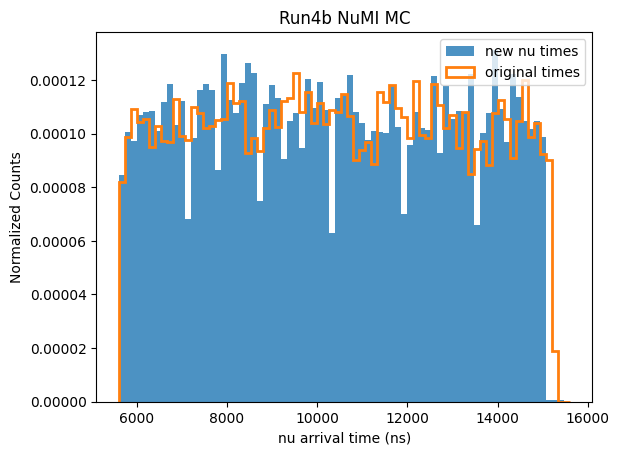

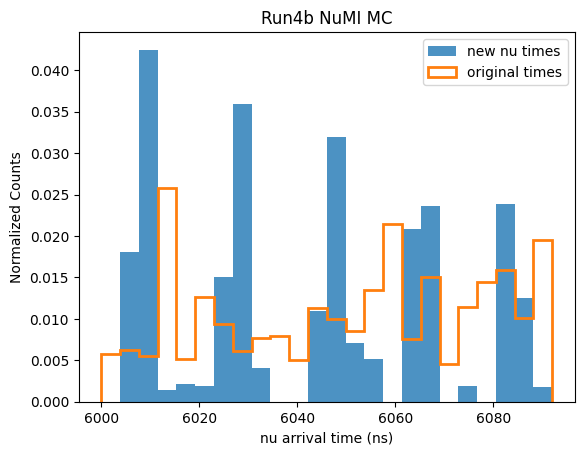

In [65]:
plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(3354+overlay_df["cor_nu_time"].to_numpy()-overlay_df["times_adjusted"].to_numpy(),bins=75,density=True,label='new nu times',range=(5600,5600+10000),alpha=0.8
        ,weights=overlay_df["net_weight"].to_numpy())
plt.hist(overlay_df["truth_nuTime"].to_numpy()*1000,bins=75,density=True,histtype='step',label='original times',range=(5600,5600+10000),lw=2
                ,weights=overlay_df["net_weight"].to_numpy())
plt.xlabel('nu arrival time (ns)')
plt.ylabel("Normalized Counts")
plt.legend()
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(3354+overlay_df["cor_nu_time"].to_numpy()-overlay_df["times_adjusted"].to_numpy(),bins=24,density=True,label='new nu times',range=(6000,6092),alpha=0.8
                ,weights=overlay_df["net_weight"].to_numpy())
plt.hist(overlay_df["truth_nuTime"].to_numpy()*1000,bins=24,density=True,histtype='step',label='original times',range=(6000,6092),lw=2
                ,weights=overlay_df["net_weight"].to_numpy())
plt.xlabel('nu arrival time (ns)')
plt.ylabel("Normalized Counts")
plt.legend()
plt.show()

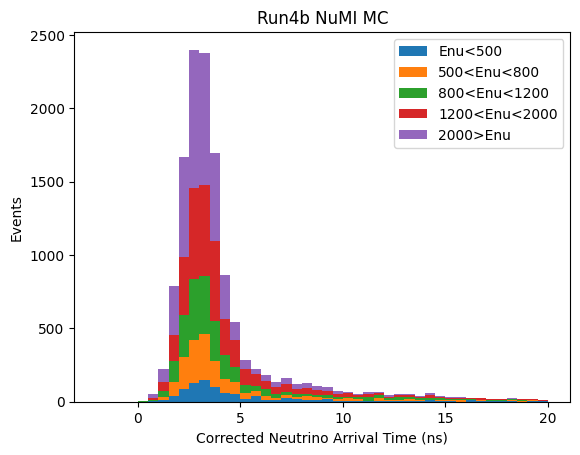

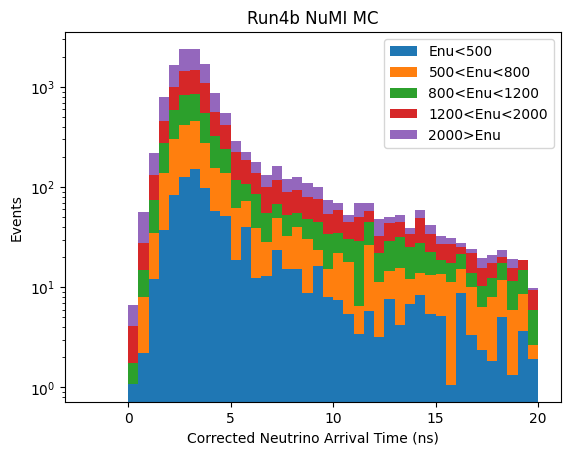

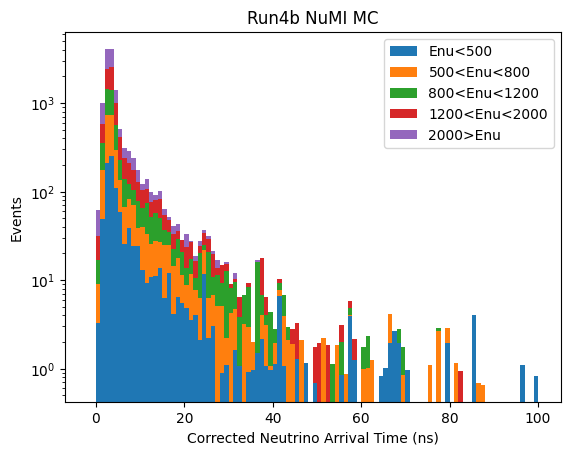

In [16]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=True,label=list_of_labels,range=(-2,100),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

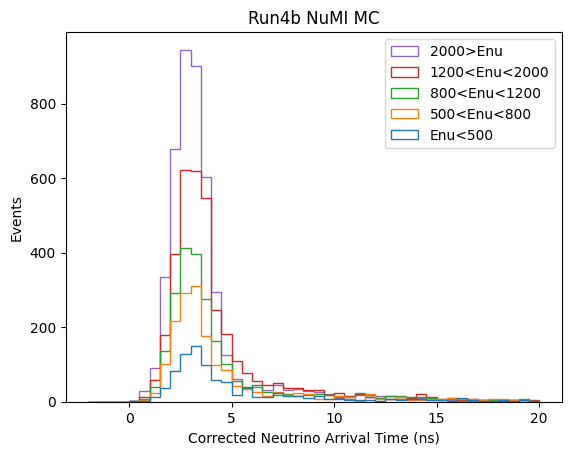

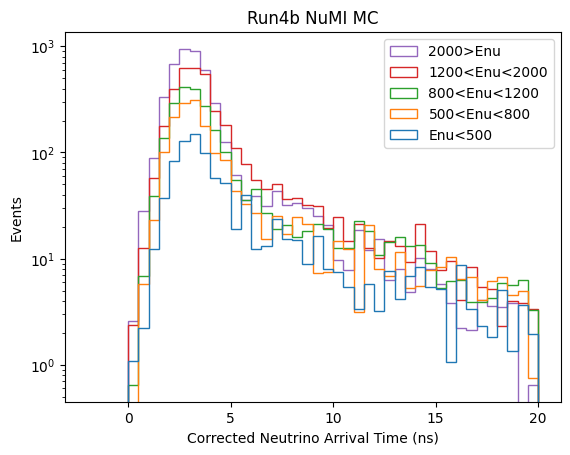

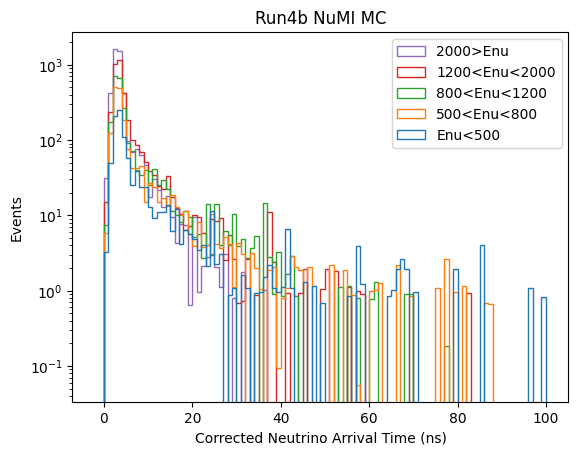

In [17]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

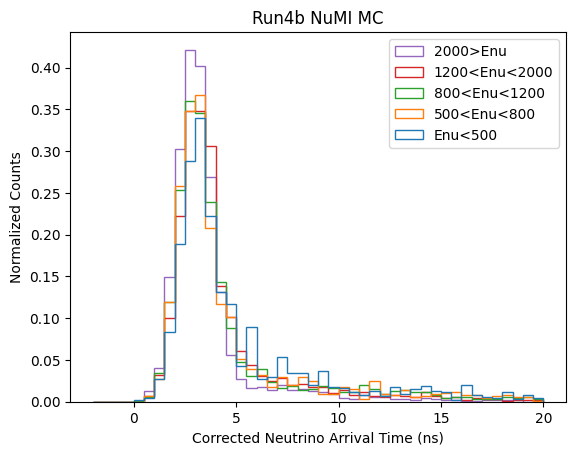

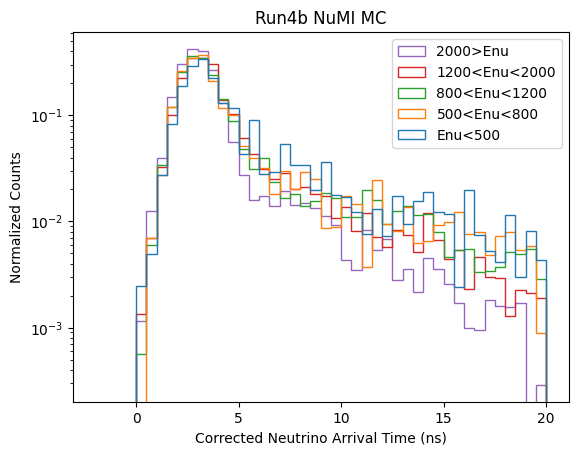

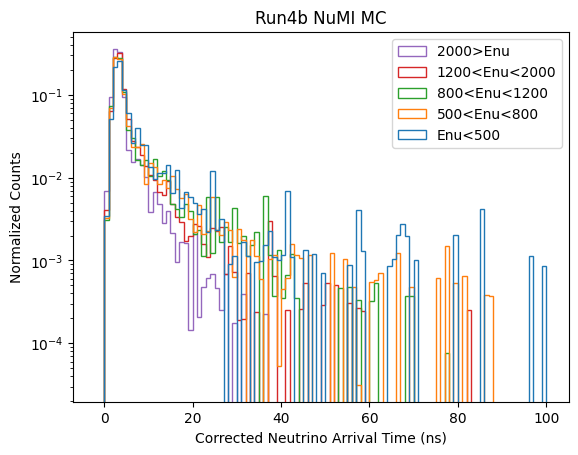

In [18]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

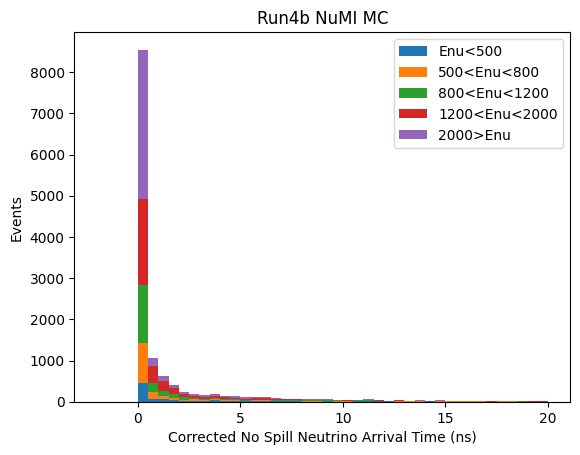

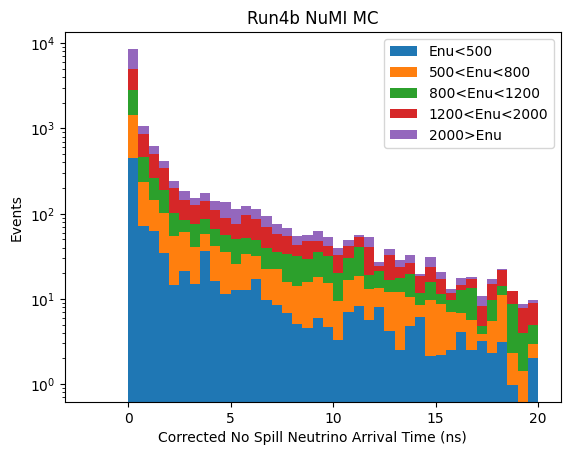

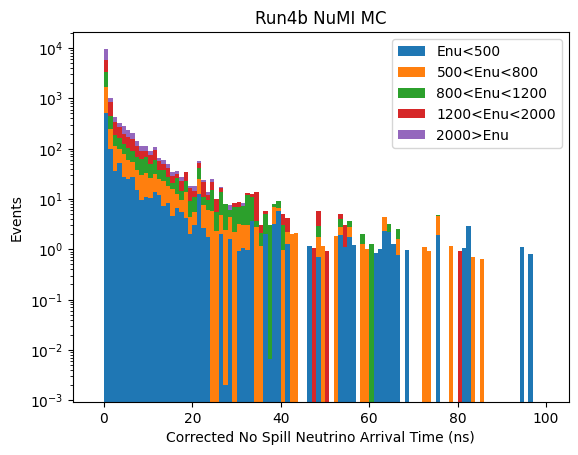

In [19]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time_nospill"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=True,label=list_of_labels,range=(-2,20),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=True,label=list_of_labels,range=(-2,100),weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

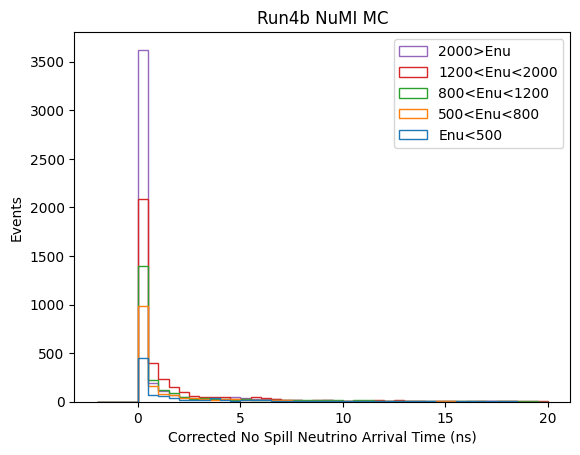

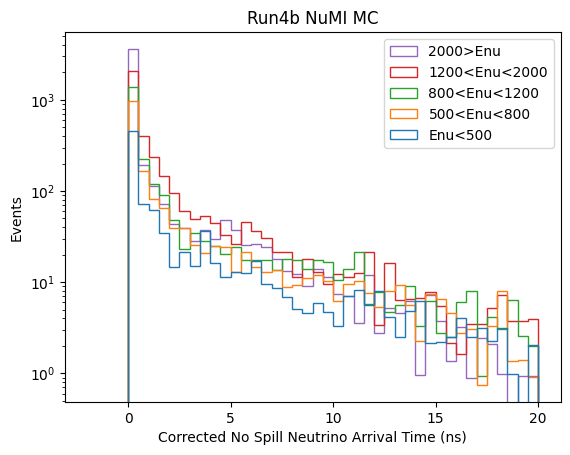

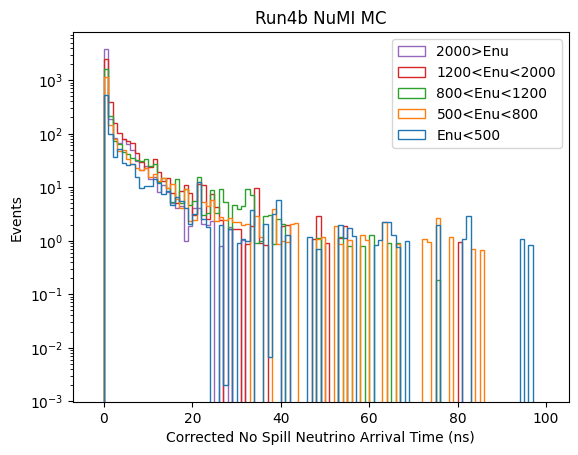

In [20]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time_nospill"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=False,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Events")
plt.yscale('log')
plt.show()

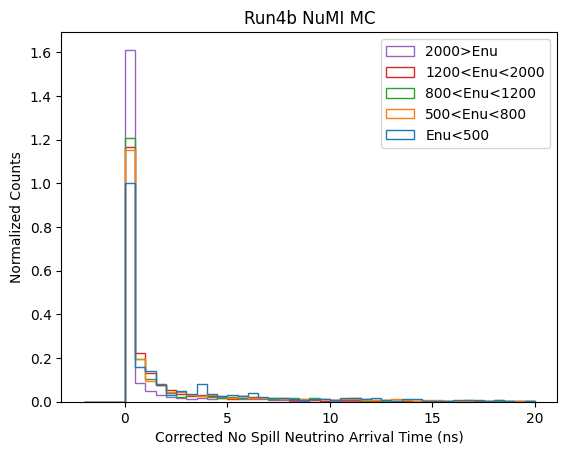

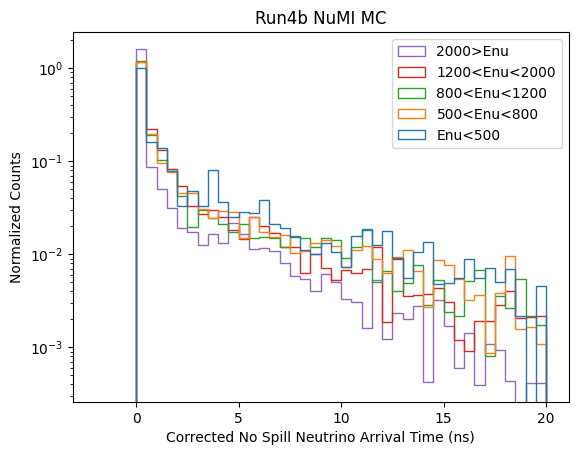

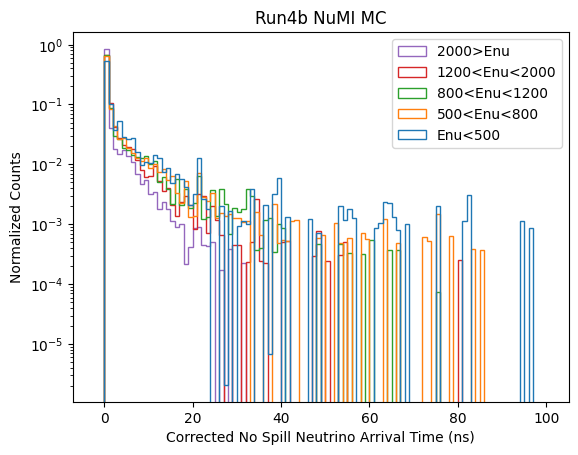

In [21]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["one_bunch_time_nospill"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["one_bunch_time_nospill"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=44,stacked=False,label=list_of_labels,range=(-2,20),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=102,stacked=False,label=list_of_labels,range=(-2,100),density=True,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.ylabel("Normalized Counts")
plt.yscale('log')
plt.show()

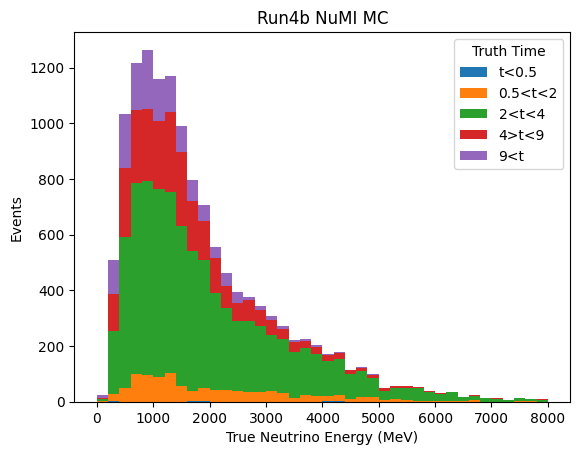

In [22]:
list_of_hist = [
    overlay_df.query("one_bunch_time<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<2 and one_bunch_time>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<4 and one_bunch_time>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<9 and one_bunch_time>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time>9")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("one_bunch_time<0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<2 and one_bunch_time>0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<4 and one_bunch_time>2")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<9 and one_bunch_time>4")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time>9")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<9',
       '9<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),stacked=True,label=list_of_labels,weights=list_of_weights)
plt.legend(title='Truth Time')
plt.xlabel('True Neutrino Energy (MeV)')
plt.ylabel("Events")
plt.show()

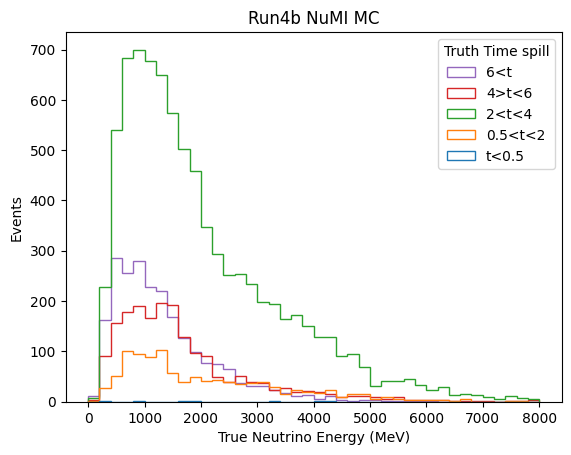

In [23]:
list_of_hist = [
    overlay_df.query("one_bunch_time<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<2 and one_bunch_time>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<4 and one_bunch_time>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<6 and one_bunch_time>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time>6")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("one_bunch_time<0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<2 and one_bunch_time>0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<4 and one_bunch_time>2")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<6 and one_bunch_time>4")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time>6")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<6',
       '6<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),histtype='step',label=list_of_labels,weights=list_of_weights)
plt.legend(title='Truth Time spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.ylabel("Events")
plt.show()

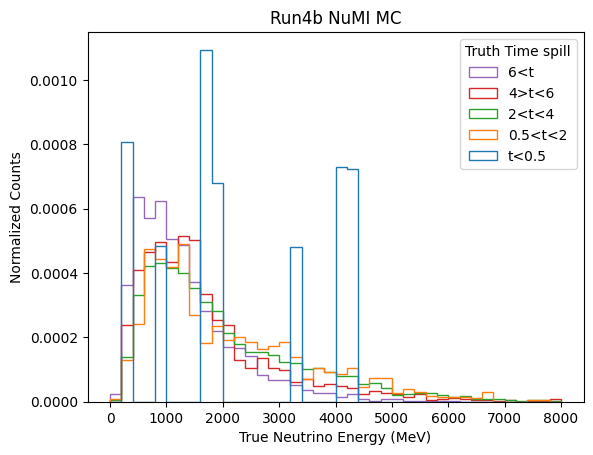

In [24]:
list_of_hist = [
    overlay_df.query("one_bunch_time<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<2 and one_bunch_time>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<4 and one_bunch_time>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time<6 and one_bunch_time>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time>6")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("one_bunch_time<0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<2 and one_bunch_time>0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<4 and one_bunch_time>2")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time<6 and one_bunch_time>4")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time>6")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<6',
       '6<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),histtype='step',label=list_of_labels,weights=list_of_weights,density=True)
plt.legend(title='Truth Time spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.ylabel("Normalized Counts")
plt.show()

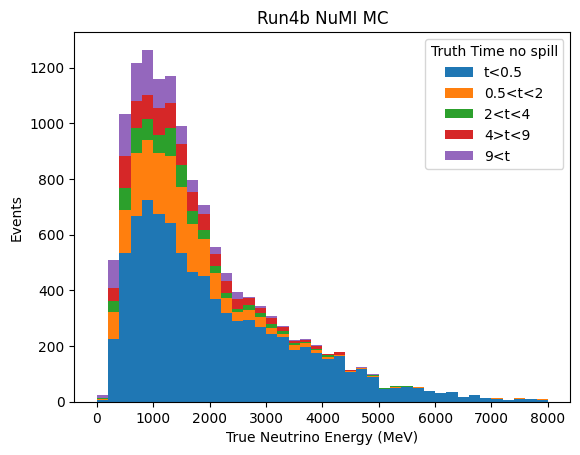

In [25]:
list_of_hist = [
    overlay_df.query("one_bunch_time_nospill<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<2 and one_bunch_time_nospill>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<4 and one_bunch_time_nospill>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<9 and one_bunch_time_nospill>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill>9")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("one_bunch_time_nospill<0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<2 and one_bunch_time_nospill>0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<4 and one_bunch_time_nospill>2")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<9 and one_bunch_time_nospill>4")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill>9")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<9',
       '9<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),stacked=True,label=list_of_labels,weights=list_of_weights)
plt.legend(title='Truth Time no spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.ylabel("Events")
plt.show()

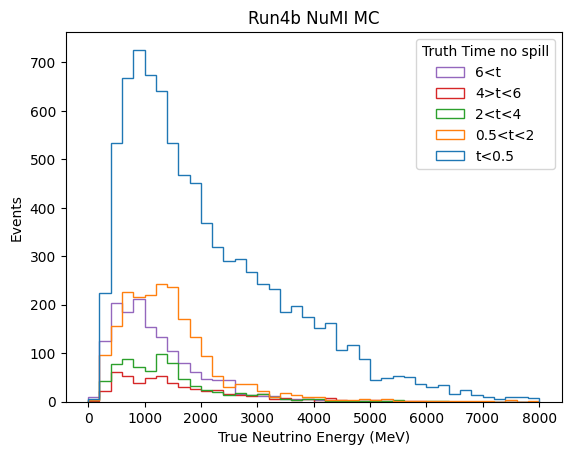

In [26]:
list_of_hist = [
    overlay_df.query("one_bunch_time_nospill<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<2 and one_bunch_time_nospill>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<4 and one_bunch_time_nospill>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<6 and one_bunch_time_nospill>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill>6")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("one_bunch_time_nospill<0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<2 and one_bunch_time_nospill>0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<4 and one_bunch_time_nospill>2")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<6 and one_bunch_time_nospill>4")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill>6")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<6',
       '6<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),histtype='step',label=list_of_labels,weights=list_of_weights)
plt.legend(title='Truth Time no spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.ylabel("Events")
plt.show()

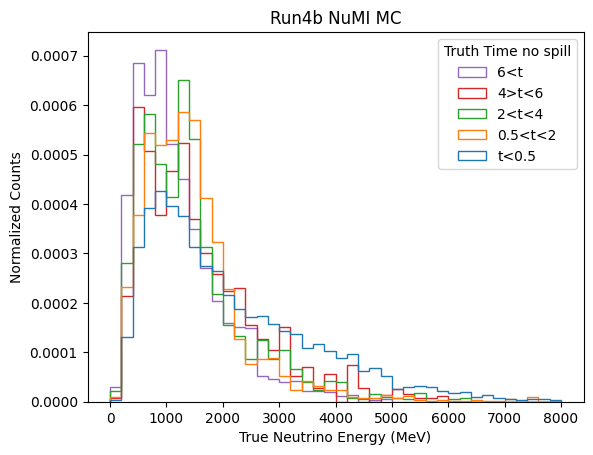

In [27]:
list_of_hist = [
    overlay_df.query("one_bunch_time_nospill<0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<2 and one_bunch_time_nospill>0.5")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<4 and one_bunch_time_nospill>2")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<6 and one_bunch_time_nospill>4")["truth_nuEnergy"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill>6")["truth_nuEnergy"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("one_bunch_time_nospill<0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<2 and one_bunch_time_nospill>0.5")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<4 and one_bunch_time_nospill>2")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill<6 and one_bunch_time_nospill>4")["net_weight"].to_numpy(),
    overlay_df.query("one_bunch_time_nospill>6")["net_weight"].to_numpy(),
    
]

list_of_labels=[
't<0.5',
       '0.5<t<2' ,
       '2<t<4' ,
    '4>t<6',
       '6<t' ,
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=40,range=(0,8000),histtype='step',label=list_of_labels,weights=list_of_weights,density=True)
plt.legend(title='Truth Time no spill')
plt.xlabel('True Neutrino Energy (MeV)')
plt.ylabel("Normalized Counts")
plt.show()

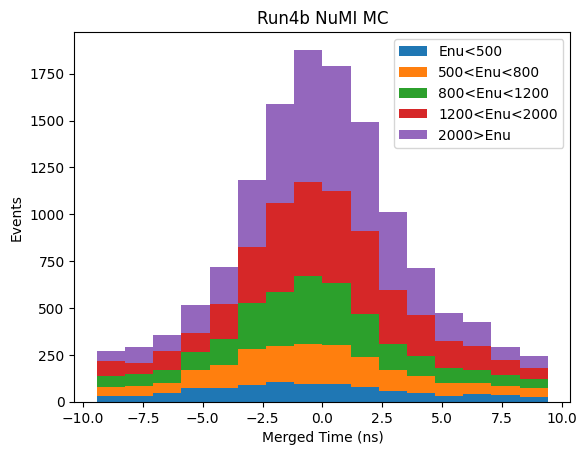

In [28]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["merge_time"].to_numpy(),
    
]


list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=16,range=(-9.42,9.42),stacked=True,label=list_of_labels,weights=list_of_weights)
plt.legend()
plt.xlabel("Merged Time (ns)")
plt.ylabel("Events")
plt.show()

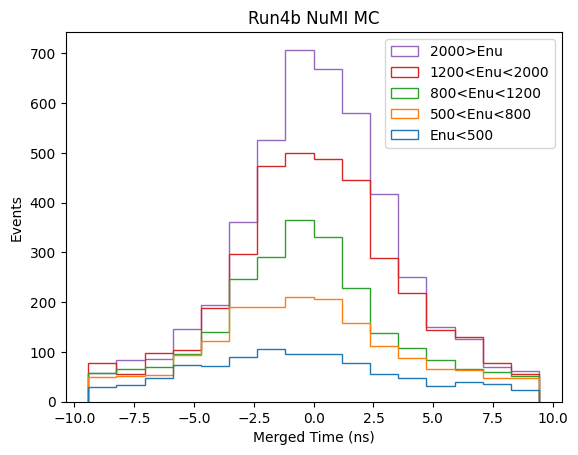

In [29]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["merge_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]

list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=16,range=(-9.42,9.42),stacked=False,label=list_of_labels,histtype='step',weights=list_of_weights)
plt.legend()
plt.xlabel("Merged Time (ns)")
plt.ylabel("Events")
plt.show()

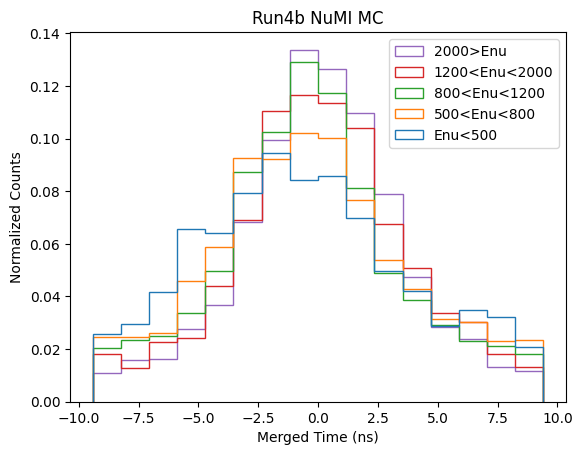

In [30]:
list_of_hist = [
    overlay_df.query("truth_nuEnergy<500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["merge_time"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["merge_time"].to_numpy(),
    
]

list_of_weights = [
    overlay_df.query("truth_nuEnergy<500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<800 and truth_nuEnergy>500")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<1200 and truth_nuEnergy>800")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy<2000 and truth_nuEnergy>1200")["net_weight"].to_numpy(),
    overlay_df.query("truth_nuEnergy>2000")["net_weight"].to_numpy(),
    
]


list_of_labels=[
'Enu<500',
   '500<Enu<800' ,
       '800<Enu<1200' ,
       '1200<Enu<2000' ,
    '2000>Enu'
]

plt.figure()
plt.title("Run4b NuMI MC")
plt.hist(list_of_hist,bins=16,range=(-9.42,9.42),stacked=False,label=list_of_labels,histtype='step',density=True,weights=list_of_weights)
plt.legend()
plt.xlabel("Merged Time (ns)")
plt.ylabel("Normalized Counts")
plt.show()

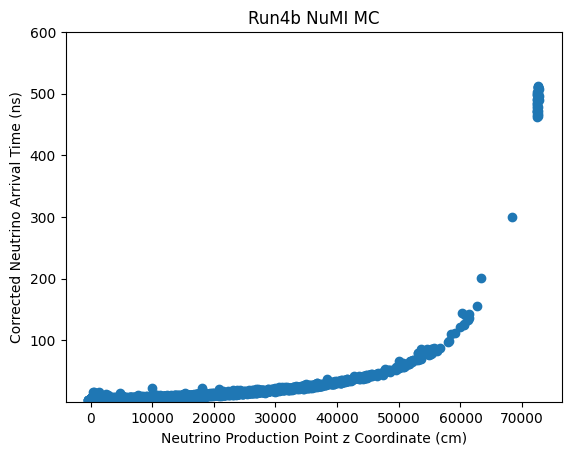

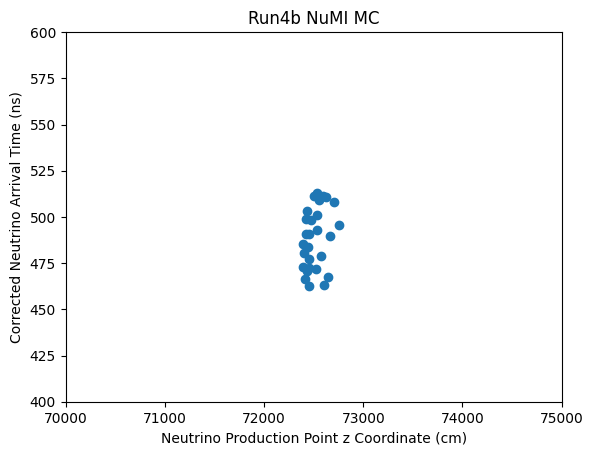

In [31]:

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.ylim(np.min(overlay_df['one_bunch_time'].to_numpy()),600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.xlim(70000,75000)
plt.ylim(400,600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()


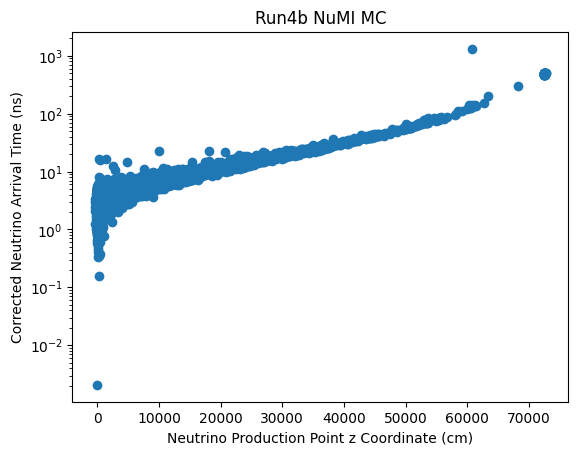

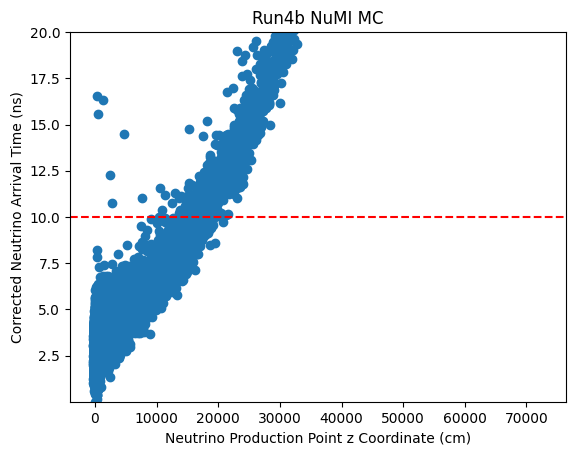

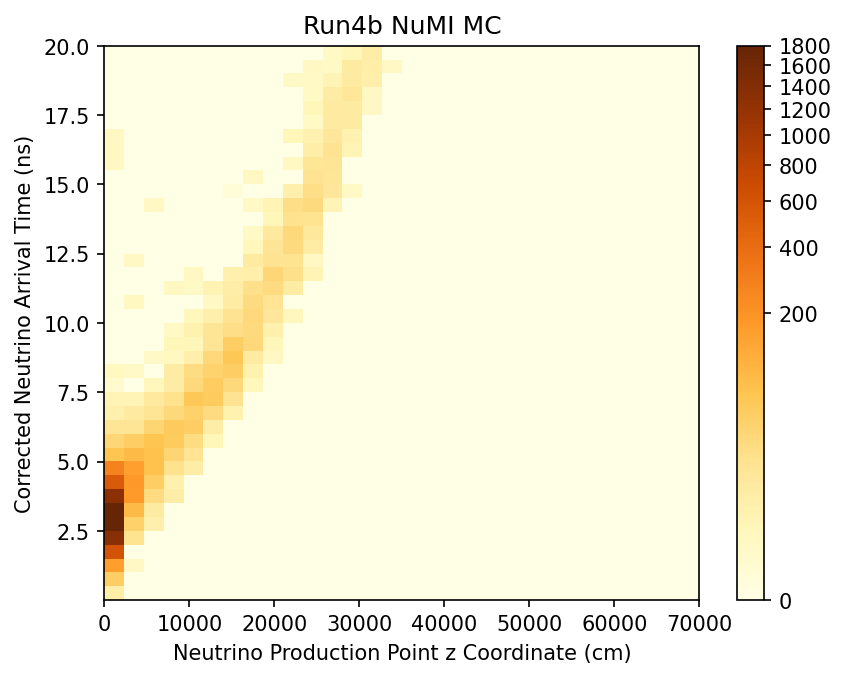

In [69]:
plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.yscale('log')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time'].to_numpy())
plt.axhline(y=10,color='red',ls='--')
plt.ylim(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+20)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()
plt.show()

vz = overlay_df['mcflux_vz']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(vz,time,range=((0,70000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+20)),bins=(30,40),
                           weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.PowerNorm(gamma=0.3,vmax=1800))
plt.colorbar(c)
#plt.axhline(y=10,color='red',ls='--')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.show()

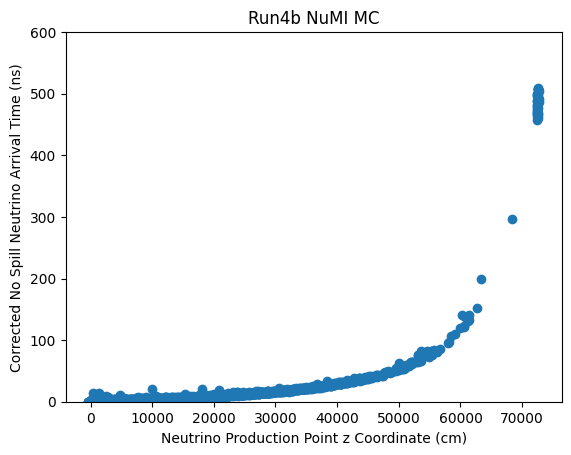

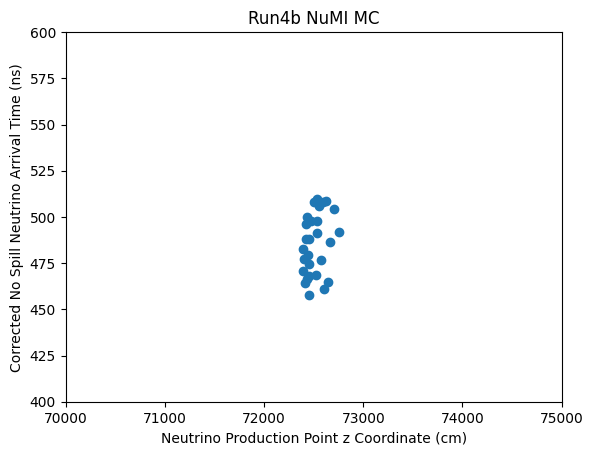

In [33]:

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time_nospill'].to_numpy())
plt.ylim(0,600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time_nospill'].to_numpy())
plt.xlim(70000,75000)
plt.ylim(400,600)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()


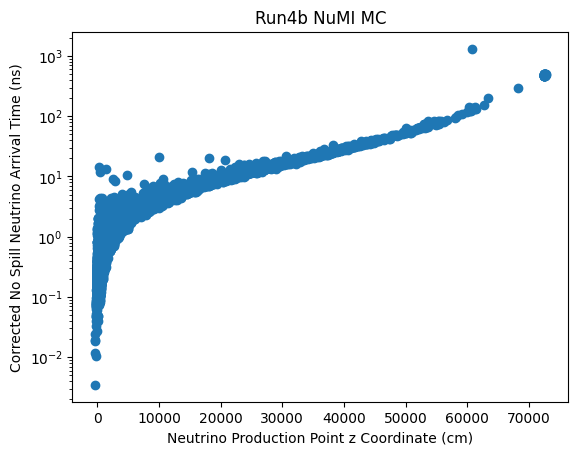

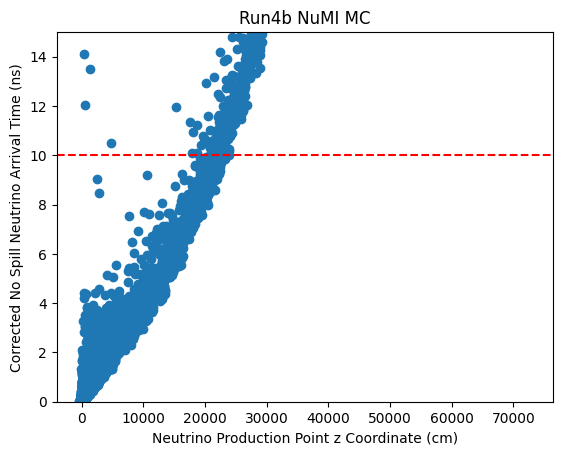

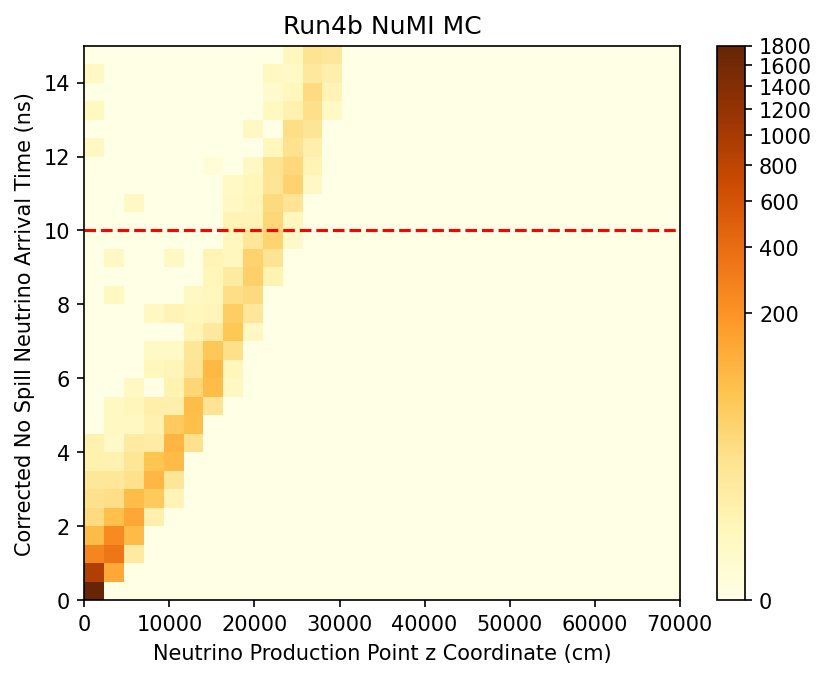

In [70]:
plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time_nospill'].to_numpy())
plt.yscale('log')
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()
plt.show()

plt.figure()
plt.title("Run4b NuMI MC")
plt.scatter(overlay_df['mcflux_vz'],overlay_df['one_bunch_time_nospill'].to_numpy())
plt.axhline(y=10,color='red',ls='--')
plt.ylim(0,15)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()
plt.show()

vz = overlay_df['mcflux_vz']
time = overlay_df['one_bunch_time_nospill'].to_numpy()
dist, x, y = np.histogram2d(vz,time,range=((0,70000),(0,15)),bins=(30,30),
                                                       weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.PowerNorm(gamma=0.3,vmax=1800))
plt.colorbar(c)
plt.xlabel("Neutrino Production Point z Coordinate (cm)")
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.show()

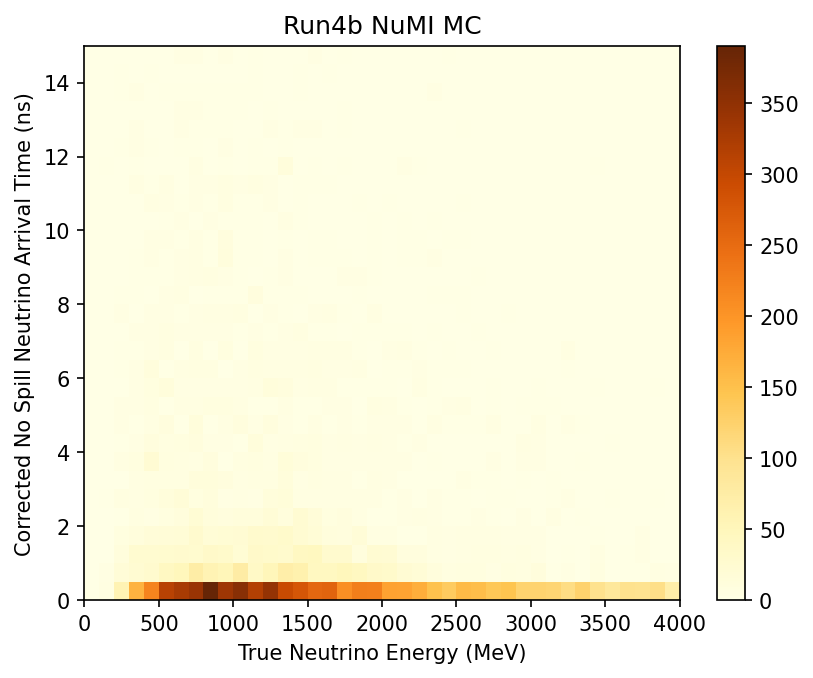

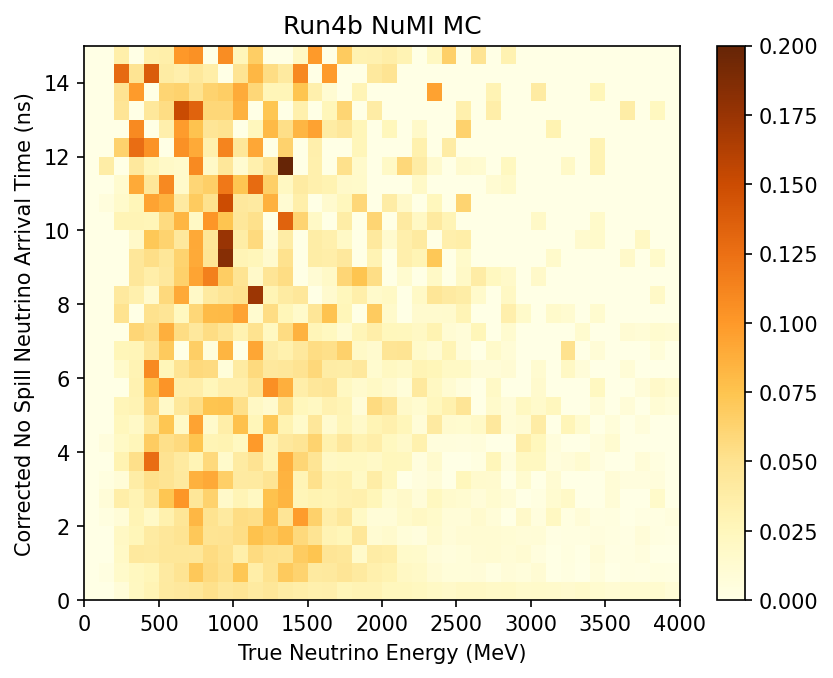

/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_4418/109783778.py:30: RuntimeWarning: invalid value encountered in divide
  c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr')


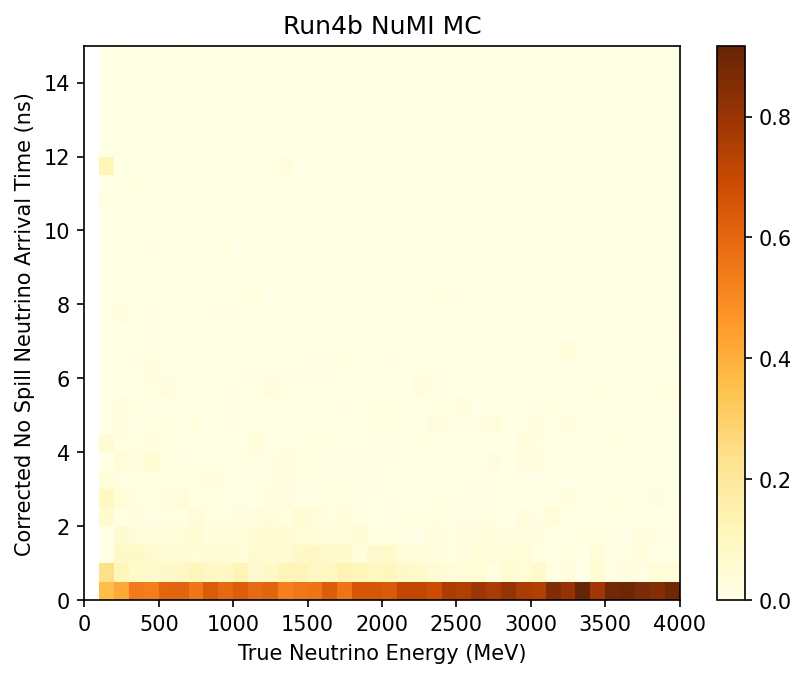

In [86]:


energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time_nospill'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(0,15)),bins=(40,30),weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr')
plt.colorbar(c)
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time_nospill'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(0,15)),bins=(40,30),weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
col_sum = dist.sum(axis=0)
c = plt.pcolormesh(x, y, (dist/col_sum).T,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time_nospill'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(0,15)),bins=(40,30),weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr')
plt.colorbar(c)
plt.ylabel("Corrected No Spill Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

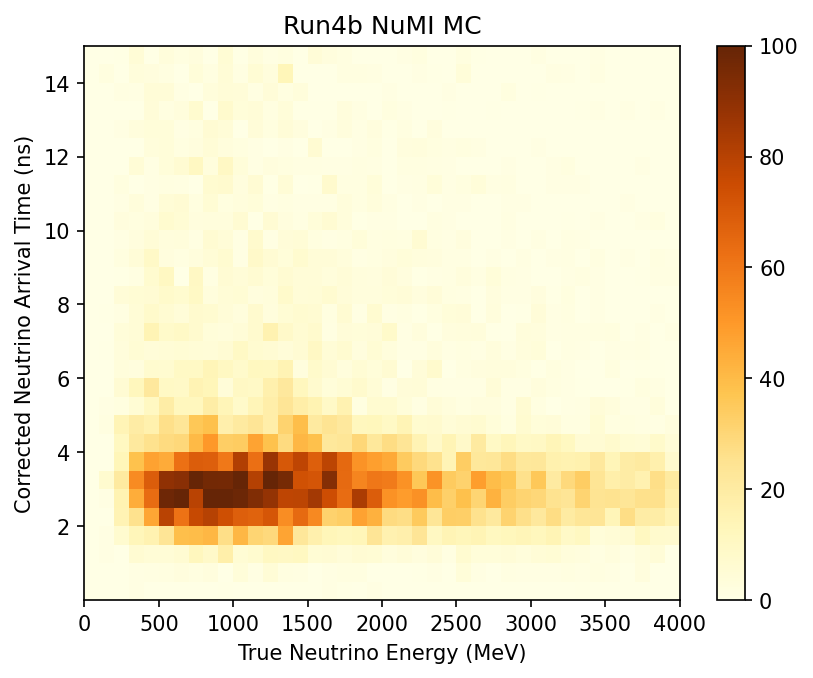

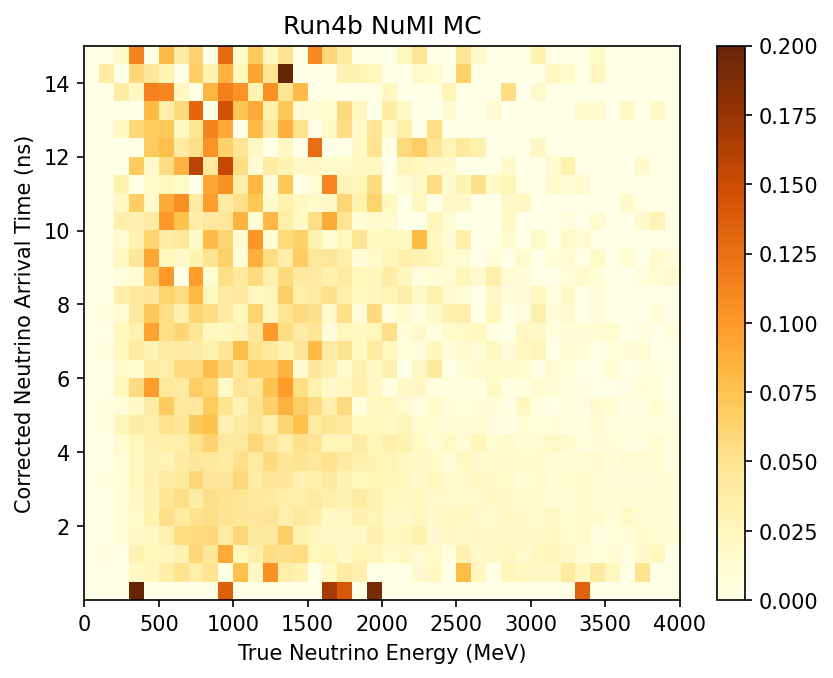

/var/folders/44/h4qhfb4d6r54v8lb5v_tptbc0000gp/T/ipykernel_4418/3244638897.py:33: RuntimeWarning: invalid value encountered in divide
  c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.3)


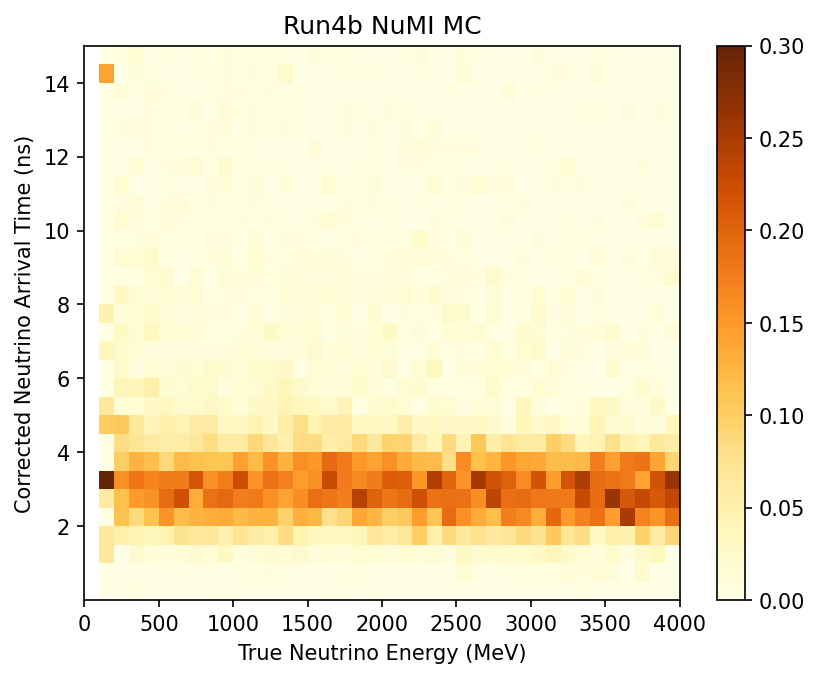

In [87]:

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+15)),bins=(40,30)
                           ,weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr',vmax=100)
plt.colorbar(c)
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+15)),bins=(40,30)
                           ,weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
col_sum = dist.sum(axis=0)
c = plt.pcolormesh(x, y, (dist/col_sum).T,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

energy = overlay_df['truth_nuEnergy']
time = overlay_df['one_bunch_time'].to_numpy()
dist, x, y = np.histogram2d(energy,time,range=((0,4000),(np.min(overlay_df['one_bunch_time'].to_numpy()),np.min(overlay_df['one_bunch_time'].to_numpy())+15)),bins=(40,30)
                           ,weights=overlay_df['net_weight'].to_numpy())
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.3)
plt.colorbar(c)
plt.ylabel("Corrected Neutrino Arrival Time (ns)")
plt.xlabel('True Neutrino Energy (MeV)')
plt.show()

data: Gaussian      mean: -0.0788   std: -0.8439   C: 63.0801
1256.1174493593023


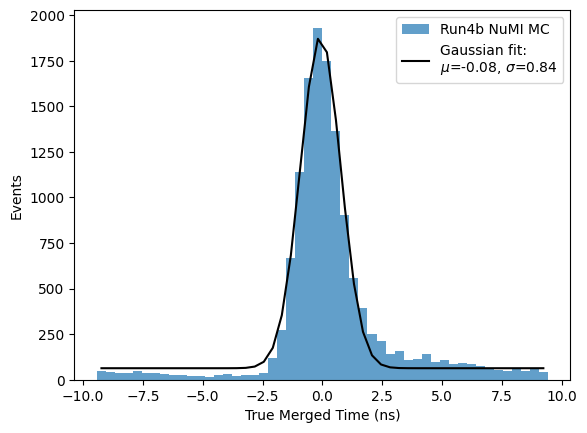

In [37]:
nbins = 50

data = overlay_df.query("merge_time_truth>-9.42 and merge_time_truth<9.42")["merge_time_truth"].to_numpy()
weights = overlay_df.query("merge_time_truth>-9.42 and merge_time_truth<9.42")["net_weight"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42),weights=weights)
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC",weights=weights)
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("True Merged Time (ns)")
plt.legend()
plt.show()

data: Gaussian      mean: -0.0652   std: -0.7486   C: 1.9636
104.20165041294527


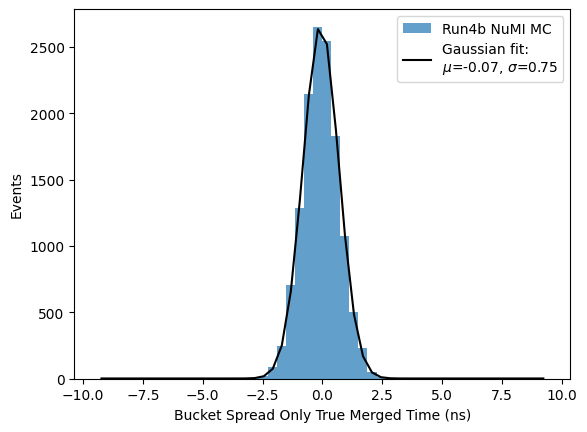

In [38]:
nbins = 50

data = overlay_df.query("merge_time_truth_spill>-9.42 and merge_time_truth_spill<9.42")["merge_time_truth_spill"].to_numpy()
weights = overlay_df.query("merge_time_truth_spill>-9.42 and merge_time_truth_spill<9.42")["net_weight"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42),weights=weights)
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC",weights=weights)
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.legend()
plt.xlabel("Bucket Spread Only True Merged Time (ns)")
plt.show()

data: Gaussian      mean: -0.0652   std: -0.7486   C: 1.9636


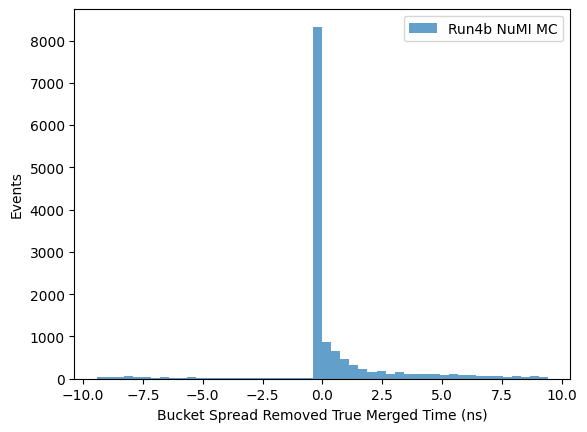

In [39]:
nbins = 50

data = overlay_df.query("merge_time_truth_nospill>-9.42 and merge_time_truth_nospill<9.42")["merge_time_truth_nospill"].to_numpy()
weights = overlay_df.query("merge_time_truth_nospill>-9.42 and merge_time_truth_nospill<9.42")["net_weight"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42),weights=weights)
x = get_bin_centers(xbins)

#popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

#chi2=0
#for i in range(len(x)):
#    pred = gaus(x,*popt)[i]
#    chi2 += (y[i]-pred)**2/pred
#print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC",weights=weights)
#plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("Bucket Spread Removed True Merged Time (ns)")
plt.legend()
plt.show()

data: Gaussian      mean: -0.1719   std: 2.6135   C: 87.9619
71.56814271752964


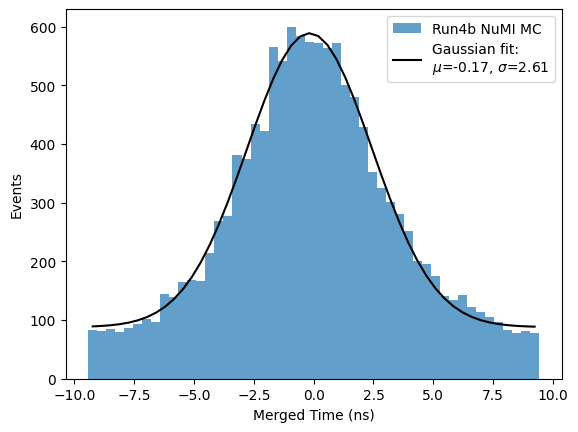

In [40]:
nbins = 50

data = overlay_df.query("merge_time>-9.42 and merge_time<9.42")["merge_time"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42))
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC")
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("Merged Time (ns)")
plt.legend()
plt.show()

data: Gaussian      mean: -0.0552   std: 2.4388   C: 46.0108
62.24813500982089


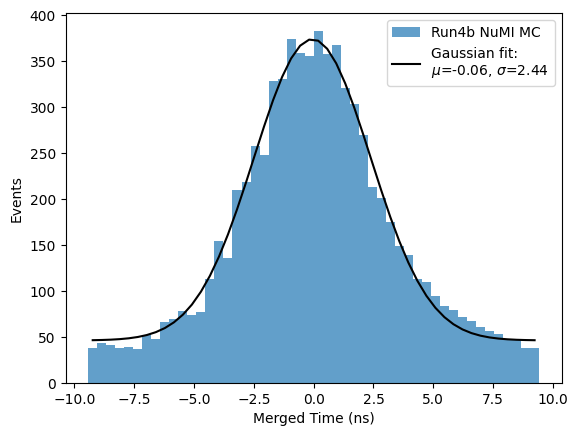

In [41]:
nbins = 50

data = overlay_df.query("merge_time>-9.42 and merge_time<9.42").query("numu_score>0.9")["merge_time"].to_numpy()
y,xbins = np.histogram(data,bins=nbins,range=(-9.42, 9.42))
x = get_bin_centers(xbins)

popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

chi2=0
for i in range(len(x)):
    pred = gaus(x,*popt)[i]
    chi2 += (y[i]-pred)**2/pred
print(chi2)


plt.figure()
plt.hist(data,bins=nbins,alpha=0.7, density=False,range=(-9.42, 9.42),label="Run4b NuMI MC")
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("Merged Time (ns)")
plt.legend()
plt.show()

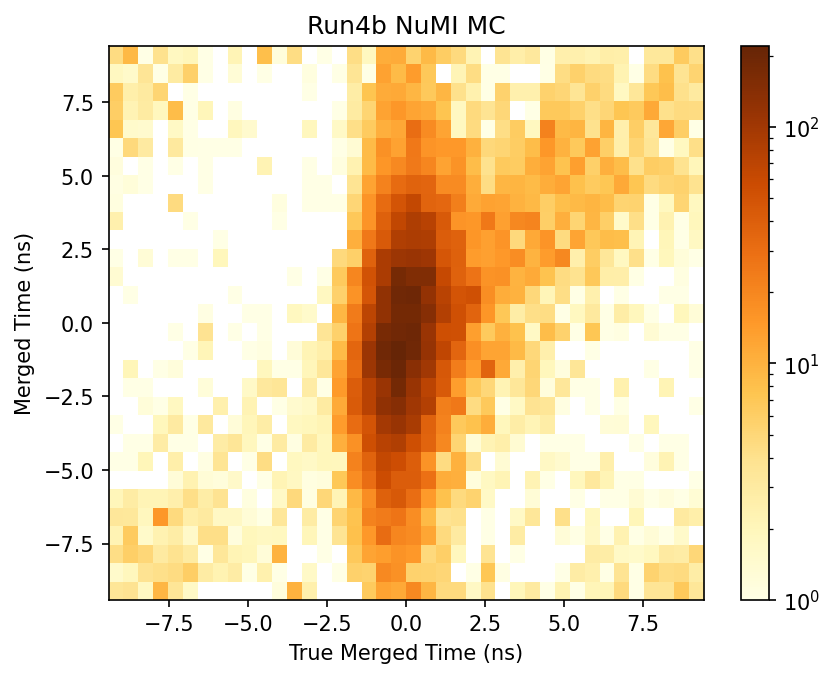

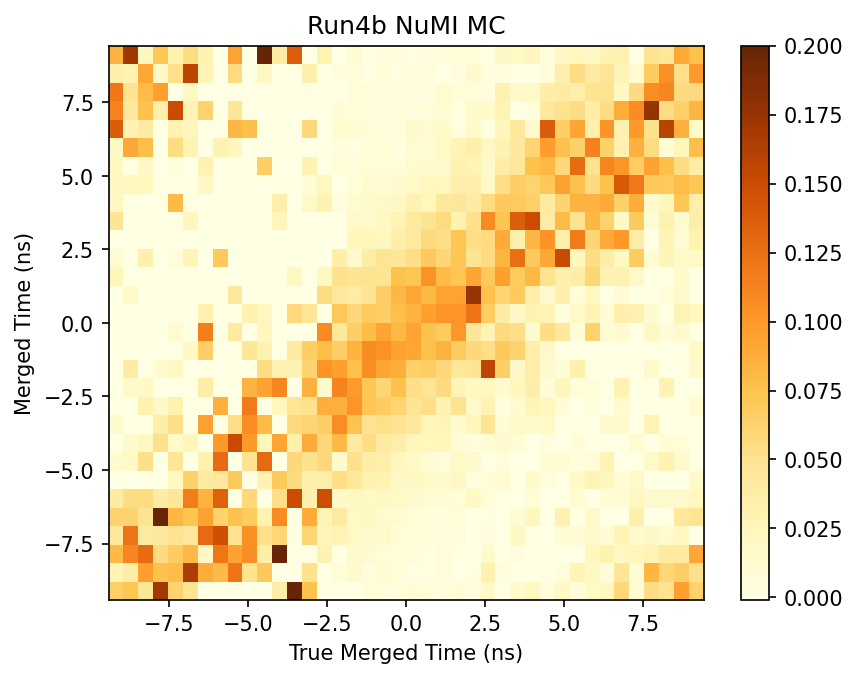

In [76]:
true_time = overlay_df['merge_time_truth'].to_numpy()
time = overlay_df['merge_time'].to_numpy()
weights = overlay_df['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(40,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df['merge_time_truth'].to_numpy()
time = overlay_df['merge_time'].to_numpy()
weights = overlay_df['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(40,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

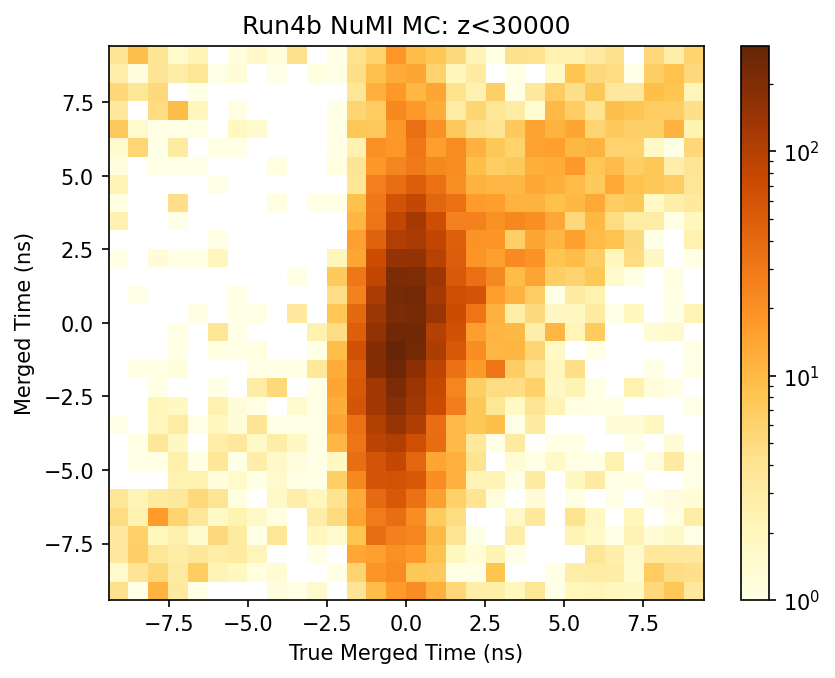

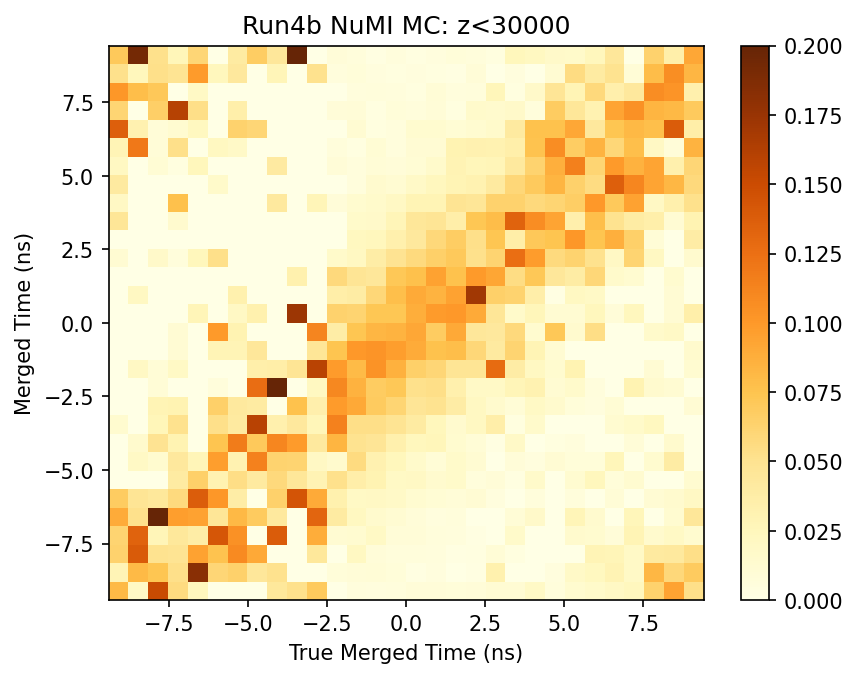

In [77]:
true_time = overlay_df.query('mcflux_vz<30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz<30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz<30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z<30000")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('mcflux_vz<30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz<30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz<30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z<30000")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

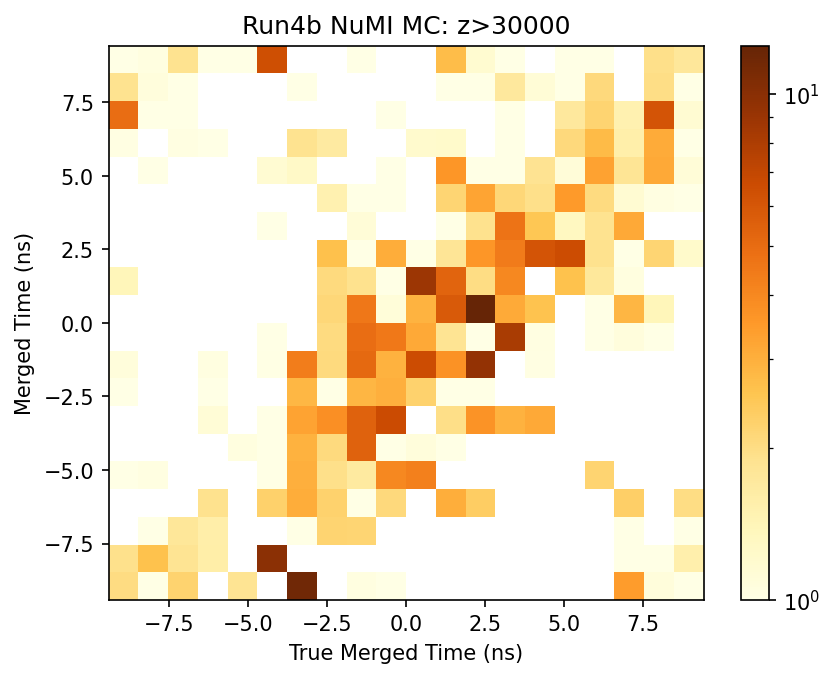

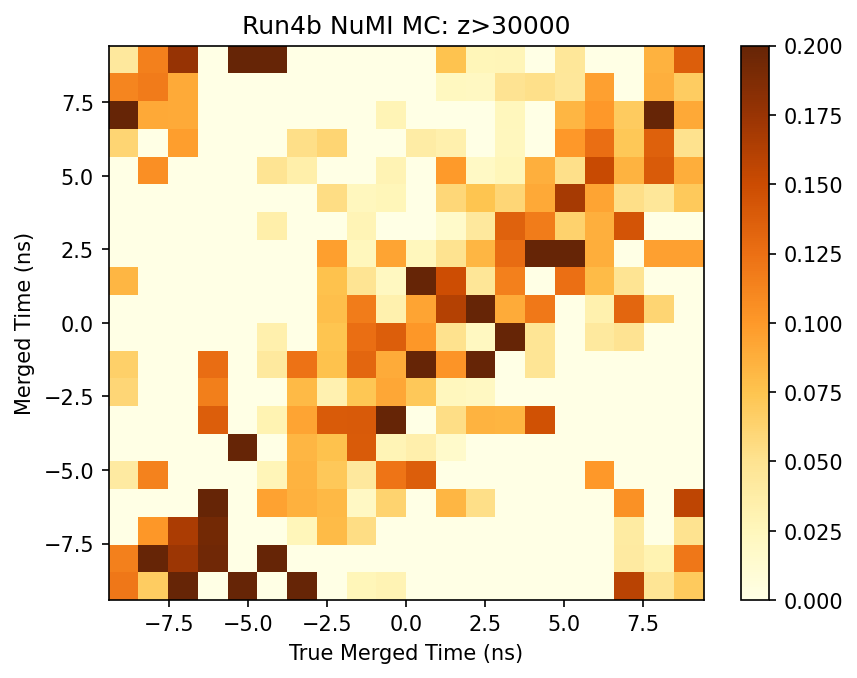

In [75]:
true_time = overlay_df.query('mcflux_vz>30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz>30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz>30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z>30000")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('mcflux_vz>30000')['merge_time_truth'].to_numpy()
time = overlay_df.query('mcflux_vz>30000')['merge_time'].to_numpy()
weights = overlay_df.query('mcflux_vz>30000')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: z>30000")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

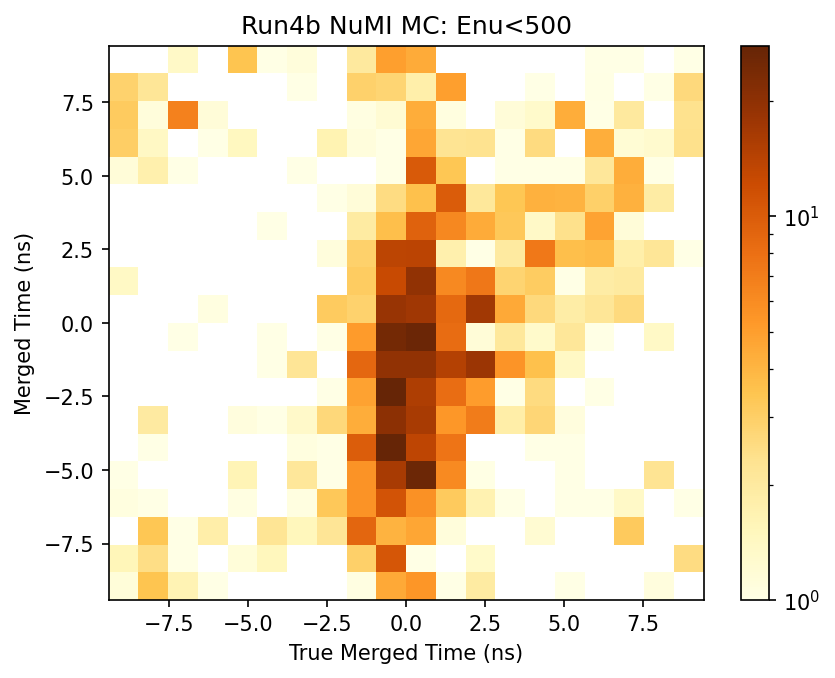

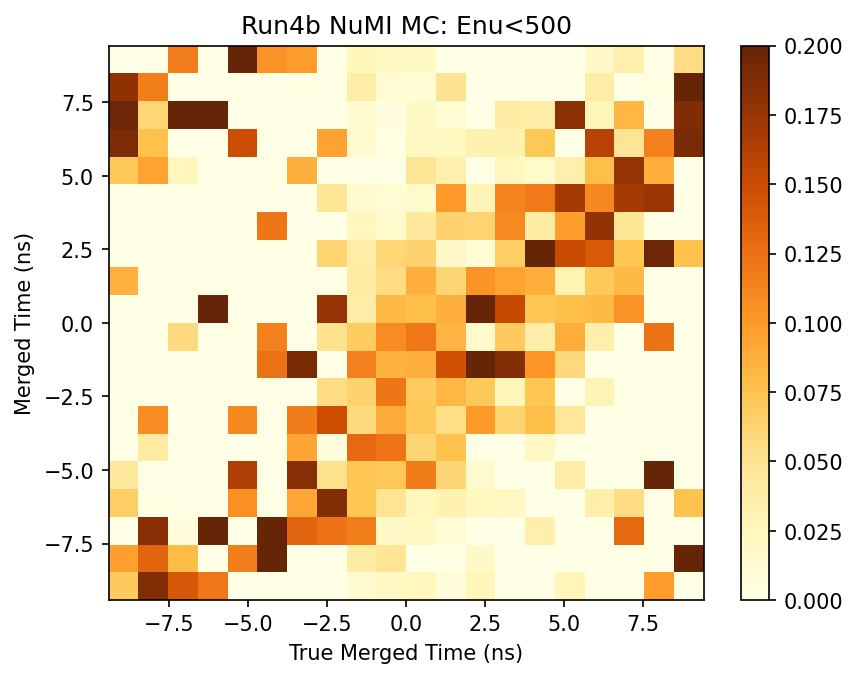

In [78]:
true_time = overlay_df.query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy<500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy<500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu<500")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy<500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy<500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(20,20),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu<500")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

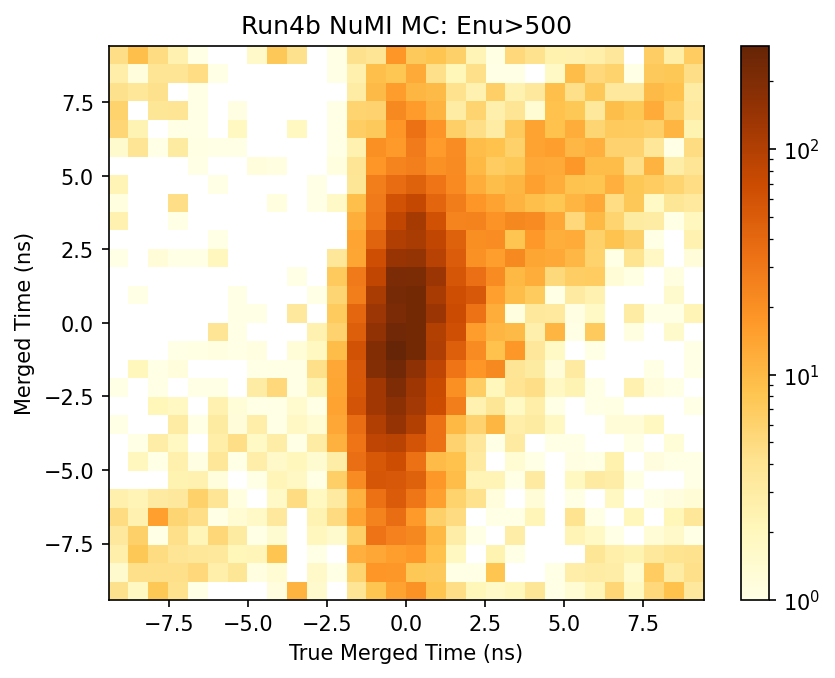

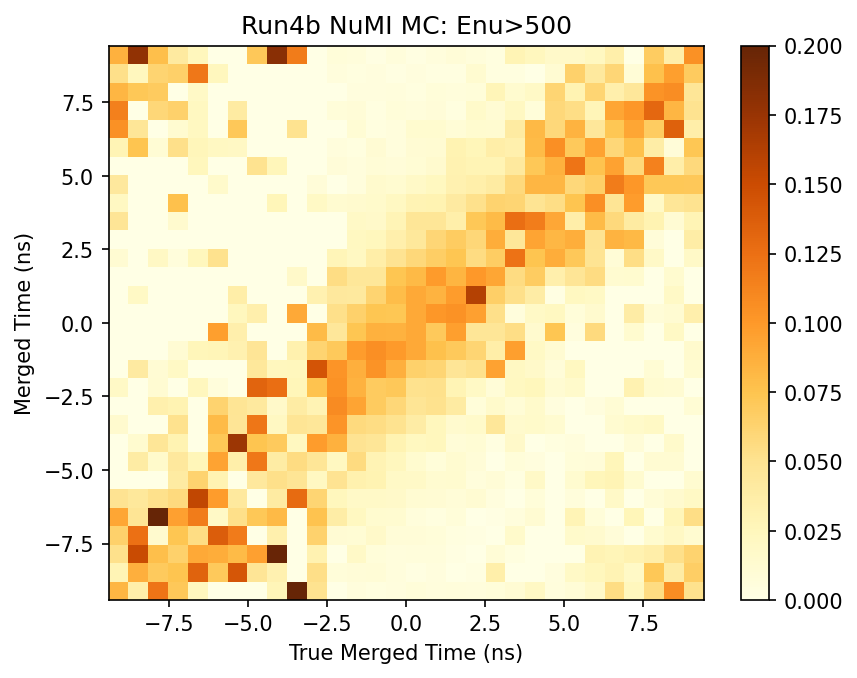

In [79]:
true_time = overlay_df.query('truth_nuEnergy>500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy>500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy>500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu>500")
c = plt.pcolormesh(x, y, dist.T,cmap='YlOrBr', norm=mpl.colors.LogNorm(vmin=1))
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

true_time = overlay_df.query('truth_nuEnergy>500')['merge_time_truth'].to_numpy()
time = overlay_df.query('truth_nuEnergy>500')['merge_time'].to_numpy()
weights = overlay_df.query('truth_nuEnergy>500')['net_weight'].to_numpy()
dist, x, y = np.histogram2d(true_time,time,range=((-9.42,9.42),(-9.42,9.42)),bins=(30,30),weights=weights)
plt.figure(dpi=150)
plt.title("Run4b NuMI MC: Enu>500")
row_sum = dist.sum(axis=1)
c = plt.pcolormesh(x, y, (dist).T/row_sum,cmap='YlOrBr',vmax=0.2)
plt.colorbar(c)
plt.ylabel('Merged Time (ns)')
plt.xlabel('True Merged Time (ns)')
plt.show()

mean: -76.19549436859415
median: -0.006056185750821896
std: 1129.8389240933873
q1: -3.1300404001071
q3: 3.036320252831683
IQR: 3.0831803264693916
FWHM: 2.1803895055734004
data: Gaussian      mean: 0.0349   std: -2.6712
data: Gaussian      mean: 0.0339   std: 2.6024   C: 11.525


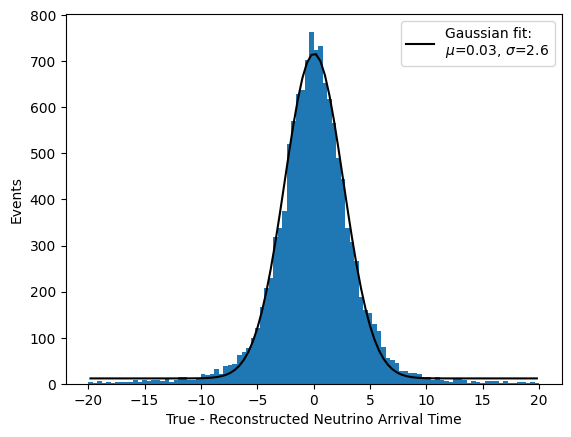

In [105]:
true_time = overlay_df.query("evtTimeNS_cor>0")['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0")["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0")['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.legend()
plt.show()


mean: 0.4396726011210041
median: 0.42630934763383266
std: 3.899273727298609
q1: -2.5532633524289845
q3: 3.4946960456883946
IQR: 3.02397969905869
FWHM: 2.1640271601002956
data: Gaussian      mean: 0.4375   std: -2.7172
data: Gaussian      mean: 0.4357   std: -2.6251   C: 14.6129


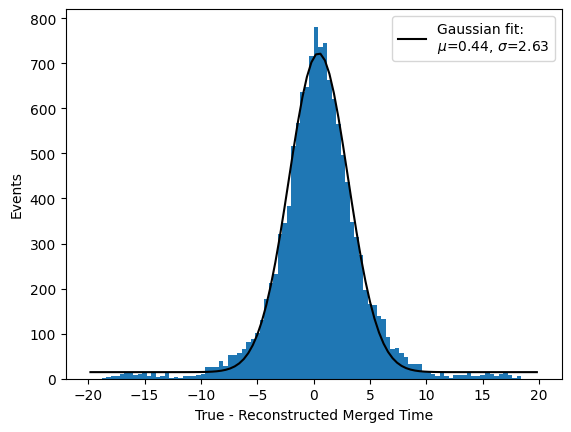

In [48]:
true_time = overlay_df.query("evtTimeNS_cor>0")['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0")['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Merged Time")
plt.legend()
plt.show()

mean: 0.31335858565579927
median: 0.31143085727899233
std: 3.6643920507493086
q1: -2.4030857421762266
q3: 3.025773624433841
IQR: 2.714429683305034
FWHM: 1.9319761327828413
data: Gaussian      mean: 0.3065   std: 2.4788
data: Gaussian      mean: 0.3066   std: 2.4169   C: 7.2365


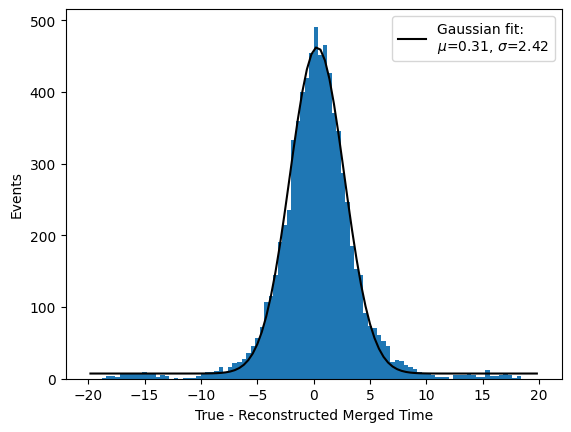

In [49]:
true_time = overlay_df.query("evtTimeNS_cor>0").query("numu_score>0.9")['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query("numu_score>0.9")['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Merged Time")
plt.show()

mean: -80.576507870348
median: -0.05521484525070264
std: 1116.5523169946687
q1: -3.1687902713633593
q3: 2.924984728141171
IQR: 3.0468874997522652
FWHM: 2.1561984743841505
data: Gaussian      mean: -0.0251   std: -2.6333
data: Gaussian      mean: -0.0261   std: -2.5645   C: 9.9824


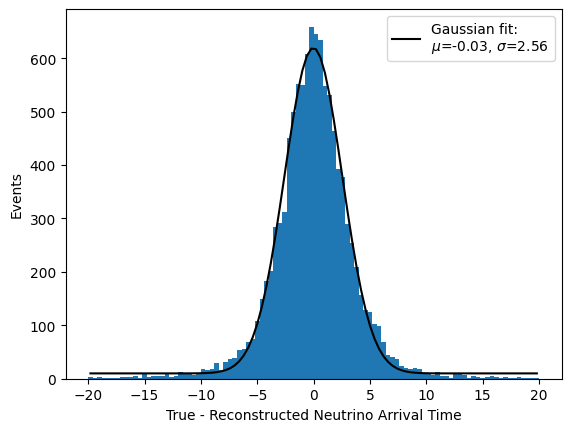

In [106]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.show()

mean: 0.3780287258270063
median: 0.38076714237740816
std: 3.248729841023484
q1: -2.5527874390688887
q3: 3.314489611119134
IQR: 2.933638525094011
FWHM: 2.0918033542427312
data: Gaussian      mean: 0.3803   std: 2.7271
data: Gaussian      mean: 0.3793   std: 2.661   C: 8.8941


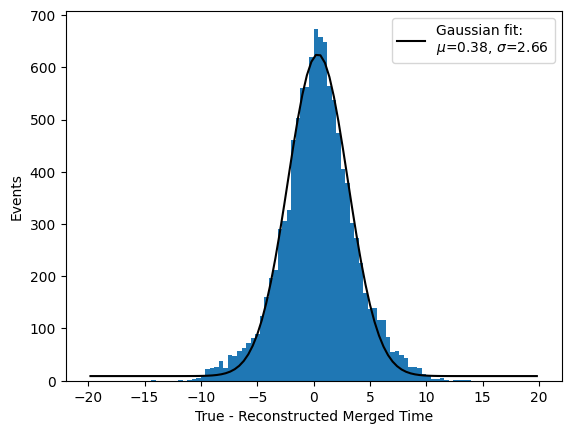

In [51]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<10000')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Merged Time")
plt.show()

mean: -55.064451775124326
median: 0.7461102669740285
std: 1287.0377560491484
q1: -2.5783781618467403
q3: 4.1022011865568775
IQR: 3.340289674201809
FWHM: 2.4226064744648905
data: Gaussian      mean: 0.8208   std: 2.8539
data: Gaussian      mean: 0.8205   std: 2.7555   C: 0.4599


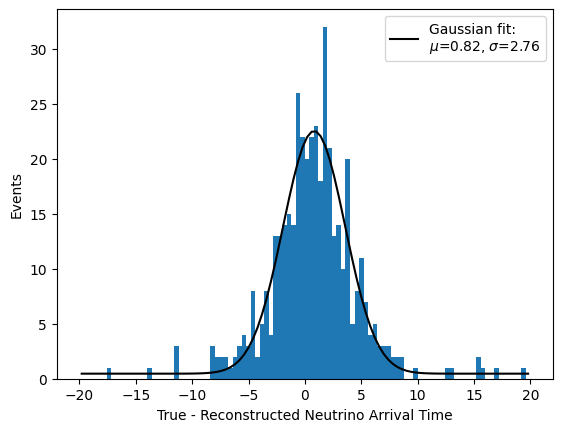

In [107]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.show()

mean: 0.5291544597423103
median: 1.0044052550233573
std: 5.598844852911148
q1: -3.11656682900677
q3: 4.338841764561582
IQR: 3.727704296784176
FWHM: 2.6710735977116573
data: Gaussian      mean: 1.1341   std: 2.8349
data: Gaussian      mean: 1.127   std: 2.601   C: 1.0167


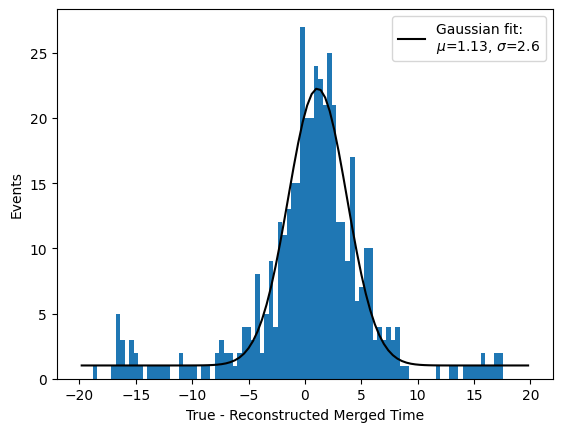

In [53]:
true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>30000')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=100,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=100,range=(-20,20))
plt.plot(x,gaus(x,*popt),color='black',label='Gaussian fit:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.legend()
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Merged Time")
plt.show()

mean: -113.75865342974885
median: 1.3524542571694838
std: 1507.8060500312972
q1: -3.197234329056482
q3: 5.046484750662965
IQR: 4.121859539859724
FWHM: 2.9870267697817465
data <500: Gaussian      mean: 1.586   std: -3.3449
data <500: Gaussian      mean: 1.594   std: -3.2576   C: 1.8279
mean: -104.89483339538856
median: 0.7056814512225174
std: 1290.722287495611
q1: -3.1337014496350823
q3: 3.8567146342941485
IQR: 3.4952080419646157
FWHM: 2.484669623200621
data 500-800: Gaussian      mean: 0.8616   std: -2.9017
data 500-800: Gaussian      mean: 0.8672   std: -2.7917   C: 4.9273
mean: -107.16101541302123
median: 0.3219632249429196
std: 1221.5473400956944
q1: -2.7530914662592476
q3: 3.2594968200678704
IQR: 3.006294143163559
FWHM: 2.133297455913149
data 500-800: Gaussian      mean: 0.3733   std: 2.6239
data 500-800: Gaussian      mean: 0.3734   std: 2.5658   C: 4.6647
mean: -65.3719171075827
median: -0.042116422318031255
std: 1115.160329494056
q1: -3.12294980673807
q3: 2.6896396199700394
IQR:

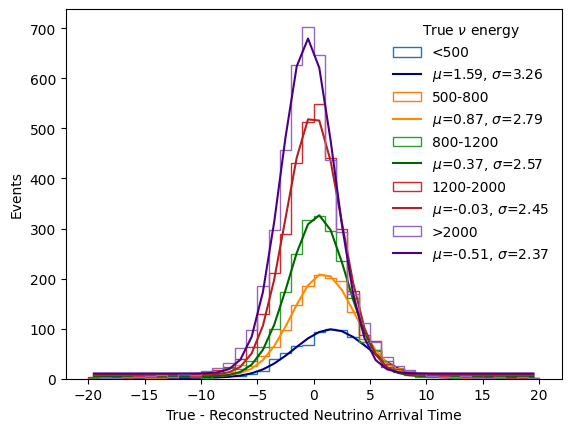

In [108]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step')
plt.plot(x,gaus(x,*popt),color='navy',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkorange',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkgreen',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='firebrick',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='indigo',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False,title=r"True $\nu$ energy")
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.show()

mean: 1.0029547689108989
median: 1.6221118272680997
std: 5.08252763087463
q1: -2.750171728284112
q3: 5.1972890024624565
IQR: 3.9737303653732843
FWHM: 2.9400364585396903
data <500: Gaussian      mean: 1.8882   std: 3.4962
data <500: Gaussian      mean: 1.9051   std: 3.3192   C: 3.4408
mean: 0.8306231767617943
median: 1.121643920056158
std: 4.5152961535770295
q1: -2.4470521649503643
q3: 4.294884154459065
IQR: 3.3709681597047148
FWHM: 2.471542746859329
data 500-800: Gaussian      mean: 1.2351   std: -2.9426
data 500-800: Gaussian      mean: 1.2403   std: -2.7911   C: 6.4429
mean: 0.7302143020880946
median: 0.7760707293887208
std: 3.9442229838220864
q1: -2.1994279252995694
q3: 3.7047733569795307
IQR: 2.95210064113955
FWHM: 2.154230072739037
data 500-800: Gaussian      mean: 0.7657   std: 2.6597
data 500-800: Gaussian      mean: 0.7653   std: -2.5688   C: 6.8534
mean: 0.3576676335003107
median: 0.39019860280609464
std: 3.7496877314109214
q1: -2.5516080497924487
q3: 3.1354807717094078
IQR: 2

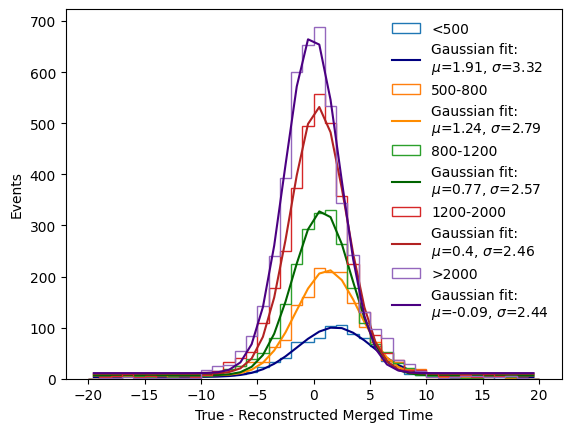

In [55]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step')
plt.plot(x,gaus(x,*popt),color='navy',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkorange',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step')
plt.plot(x,gaus(x,*popt),color='darkgreen',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='firebrick',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20))
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step')
plt.plot(x,gaus(x,*popt),color='indigo',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False,title=r"True $\nu$ energy")
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Merged Time")
plt.show()

mean: -113.75865342974885
median: 1.3524542571694838
std: 1507.8060500312972
q1: -3.197234329056482
q3: 5.046484750662965
IQR: 4.121859539859724
FWHM: 2.9870267697817465
data <500: Gaussian      mean: 1.586   std: 3.3449
data <500: Gaussian      mean: 1.594   std: 3.2576   C: 0.0021
mean: -104.89483339538856
median: 0.7056814512225174
std: 1290.722287495611
q1: -3.1337014496350823
q3: 3.8567146342941485
IQR: 3.4952080419646157
FWHM: 2.484669623200621
data 500-800: Gaussian      mean: 0.8616   std: 2.9017
data 500-800: Gaussian      mean: 0.8672   std: 2.7917   C: 0.003
mean: -107.16101541302123
median: 0.3219632249429196
std: 1221.5473400956944
q1: -2.7530914662592476
q3: 3.2594968200678704
IQR: 3.006294143163559
FWHM: 2.133297455913149
data 500-800: Gaussian      mean: 0.3733   std: 2.6239
data 500-800: Gaussian      mean: 0.3734   std: 2.5658   C: 0.0021
mean: -65.3719171075827
median: -0.042116422318031255
std: 1115.160329494056
q1: -3.12294980673807
q3: 2.6896396199700394
IQR: 2.90

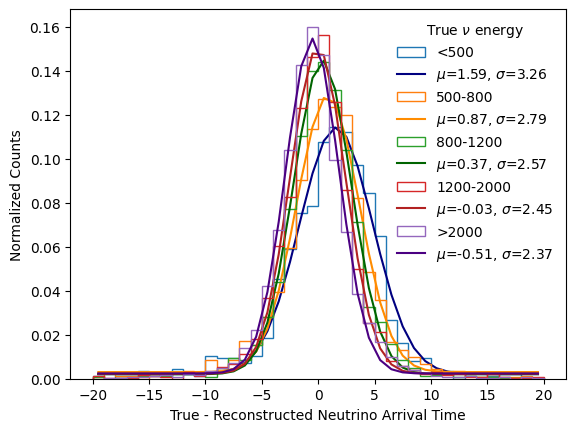

In [109]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='navy',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkorange',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkgreen',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='firebrick',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='indigo',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False,title=r"True $\nu$ energy")
plt.ylabel("Normalized Counts")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.show()

mean: 1.0029547689108989
median: 1.6221118272680997
std: 5.08252763087463
q1: -2.750171728284112
q3: 5.1972890024624565
IQR: 3.9737303653732843
FWHM: 2.9400364585396903
data <500: Gaussian      mean: 1.8882   std: 3.4963
data <500: Gaussian      mean: 1.9051   std: 3.3192   C: 0.0036
mean: 0.8306231767617943
median: 1.121643920056158
std: 4.5152961535770295
q1: -2.4470521649503643
q3: 4.294884154459065
IQR: 3.3709681597047148
FWHM: 2.471542746859329
data 500-800: Gaussian      mean: 1.2351   std: 2.9425
data 500-800: Gaussian      mean: 1.2403   std: 2.7911   C: 0.0038
mean: 0.7302143020880946
median: 0.7760707293887208
std: 3.9442229838220864
q1: -2.1994279252995694
q3: 3.7047733569795307
IQR: 2.95210064113955
FWHM: 2.154230072739037
data 500-800: Gaussian      mean: 0.7657   std: 2.6597
data 500-800: Gaussian      mean: 0.7653   std: 2.5688   C: 0.0029
mean: 0.3576676335003107
median: 0.39019860280609464
std: 3.7496877314109214
q1: -2.5516080497924487
q3: 3.1354807717094078
IQR: 2.84

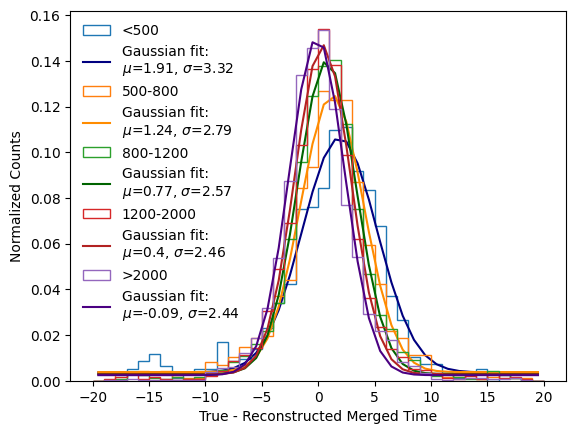

In [57]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy<500')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<500',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='navy',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>500 and truth_nuEnergy<800')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='500-800',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkorange',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>800 and truth_nuEnergy<1200')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='800-1200',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkgreen',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>1200 and truth_nuEnergy<2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1200-2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='firebrick',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('truth_nuEnergy>2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='indigo',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False,title=r"True $\nu$ energy")
plt.ylabel("Normalized Counts")
plt.xlabel("True - Reconstructed Merged Time")
plt.show()

mean: -76.19549436859415
median: -0.006056185750821896
std: 1129.8389240933873
q1: -3.1300404001071
q3: 3.036320252831683
IQR: 3.0831803264693916
FWHM: 2.1803895055734004
data: Gaussian      mean: 0.0324   std: 2.6672
data: Gaussian      mean: 0.0313   std: 2.5984   C: 5.7776
data: Gaussian     mean1: 0.0282  std1: 2.1901    mean2: 0.0282  std2: 4.4478   a1: 281.5264   a2: 85.6507


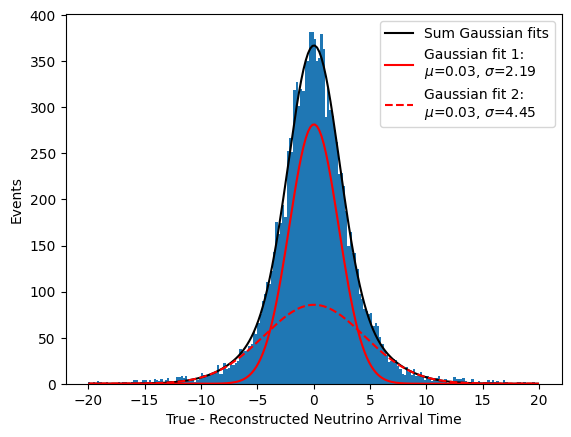

In [110]:
true_time = overlay_df.query("evtTimeNS_cor>0")['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0")["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0")['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=200,range=(-20, 20))
x = get_bin_centers(xbins)
popt1,pcov1 = curve_fit(gaus_noC,x,y)
print("data: Gaussian      mean:",round(popt1[1],4),"  std:",round(popt1[2],4))
popt2,pcov2 = curve_fit(gaus,x,y)
print("data: Gaussian      mean:",round(popt2[1],4),"  std:",round(popt2[2],4),"  C:",round(popt2[3],4))

popt,pcov = curve_fit(gaus_sum,x,y,p0=(popt1[0]*0.2,popt1[1],popt1[2],popt1[0]*0.5,popt1[2]*2))
print("data: Gaussian     mean1:",round(popt[1],4)," std1:",round(popt[2],4),"   mean2:",round(popt[1],4)," std2:",round(popt[4],4),"  a1:",round(popt[0],4),"  a2:",round(popt[3],4))

plt.figure()
plt.hist(true_time-time+offset,bins=200,range=(-20,20))
plt.plot(x,gaus_sum(x,*popt),color='black',label='Sum Gaussian fits')
plt.plot(x,gaus_noC(x,*[popt[0],popt[1],popt[2]]),color='red',label='Gaussian fit 1:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")
plt.plot(x,gaus_noC(x,*[popt[3],popt[1],popt[4]]),color='red',label='Gaussian fit 2:'+'\n'+f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[4]),2)}",ls="--")
plt.ylabel("Events")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.legend()
plt.show()



mean: -78.12645068983147
median: -0.10623570795087289
std: 1118.0779107173657
q1: -3.1779912929093914
q3: 2.903025960259147
IQR: 3.040508626584269
FWHM: 2.1521610292765296
data <500: Gaussian      mean: -0.0826   std: 2.631
data <500: Gaussian      mean: -0.0836   std: 2.5613   C: 0.0023
mean: -127.93996087833693
median: -0.002654544194228947
std: 1208.0293948997974
q1: -3.4140151146967037
q3: 2.7378137990155302
IQR: 3.075914456856117
FWHM: 2.188099837842037
data 500-800: Gaussian      mean: 0.1041   std: 2.6973
data 500-800: Gaussian      mean: 0.1065   std: 2.6321   C: 0.0022
mean: -120.56693486372296
median: 0.06021534357478231
std: 1208.8465896828761
q1: -3.0904511449956407
q3: 2.6905521608496565
IQR: 2.890501652922649
FWHM: 2.0487776361685532
data 500-800: Gaussian      mean: 0.1493   std: 2.5847
data 500-800: Gaussian      mean: 0.1531   std: 2.5234   C: 0.0022
mean: -57.084409087487074
median: 0.19609848690743092
std: 1063.7982723886923
q1: -2.9959385344345355
q3: 3.427671784522

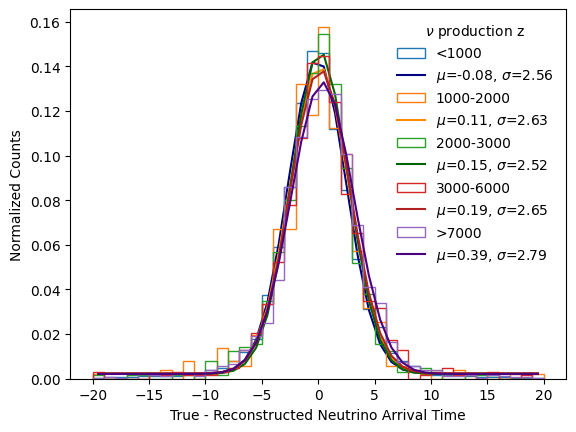

In [111]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<1000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<1000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<1000')['evtTimeNS_cor'].to_numpy()
offset = 5750.7
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<1000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='navy',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>1000 and mcflux_vz<2000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>1000 and mcflux_vz<2000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>1000 and mcflux_vz<2000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1000-2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkorange',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>2000 and mcflux_vz<3000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>2000 and mcflux_vz<3000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>2000 and mcflux_vz<3000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='2000-3000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkgreen',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>3000 and mcflux_vz<6000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>3000 and mcflux_vz<6000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>3000 and mcflux_vz<6000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='3000-6000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='firebrick',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>6000')['cor_nu_time'].to_numpy()-overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>6000')["times_adjusted"].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>6000')['evtTimeNS_cor'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>7000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='indigo',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False,title=r"$\nu$ production z")
plt.ylabel("Normalized Counts")
plt.xlabel("True - Reconstructed Neutrino Arrival Time")
plt.show()

mean: 0.29917342305099703
median: 0.32045990066762897
std: 3.2232471098747246
q1: -2.613051340900711
q3: 3.255644224767784
IQR: 2.9343477828342475
FWHM: 2.0872982913593607
data <500: Gaussian      mean: 0.3327   std: 2.7251
data <500: Gaussian      mean: 0.3314   std: 2.6592   C: 0.002
mean: 0.46986578533857726
median: 0.5534174202330178
std: 3.3222405395774186
q1: -2.7070666920690383
q3: 3.343819856965236
IQR: 3.025443274517137
FWHM: 2.1511242009205684
data 500-800: Gaussian      mean: 0.5439   std: 2.8496
data 500-800: Gaussian      mean: 0.5463   std: 2.7882   C: 0.0018
mean: 0.49714845882831155
median: 0.5309396725160695
std: 3.15827948669873
q1: -2.3412441374931223
q3: 3.1893138210338656
IQR: 2.7652789792634938
FWHM: 1.9782028940672107
data 500-800: Gaussian      mean: 0.5113   std: 2.711
data 500-800: Gaussian      mean: 0.5131   std: 2.6554   C: 0.0018
mean: 0.6147189469782224
median: 0.5547679326623438
std: 3.3670060119373724
q1: -2.469749282325574
q3: 3.639791840208198
IQR: 3.

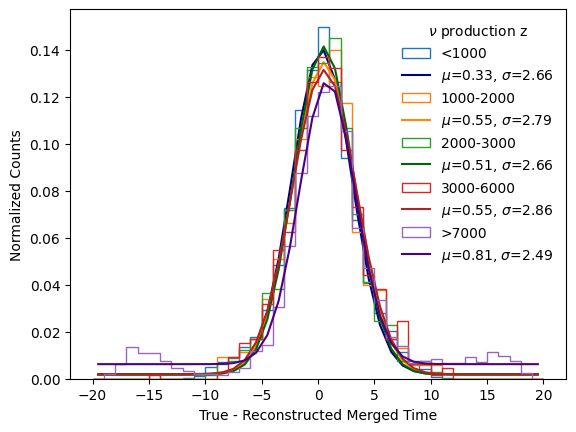

In [112]:
plt.figure()

true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<1000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz<1000')['merge_time'].to_numpy()
offset = 0
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data <500: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='<1000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='navy',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>1000 and mcflux_vz<2000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>1000 and mcflux_vz<2000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='1000-2000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkorange',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>2000 and mcflux_vz<3000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>2000 and mcflux_vz<3000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='2000-3000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='darkgreen',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")



true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>3000 and mcflux_vz<6000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>3000 and mcflux_vz<6000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='3000-6000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='firebrick',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


true_time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>6000')['merge_time_truth'].to_numpy()
time = overlay_df.query("evtTimeNS_cor>0").query('mcflux_vz>6000')['merge_time'].to_numpy()
print("mean:",np.mean(true_time-time)+offset)
print("median:",np.median(true_time-time)+offset)
print("std:",np.std(true_time-time))
q = np.quantile(true_time-time+offset, [0.16, 0.5, 0.84])
print("q1:",q[0])
print("q3:",q[2])
print("IQR:",(q[2]-q[0])/2)
print("FWHM:",np.sqrt(q[0]*q[0]+q[2]*q[2])/2)

y,xbins = np.histogram(true_time-time+np.ones_like(time)*offset,bins=40,range=(-20, 20),density=True)
x = get_bin_centers(xbins)
popt,pcov = curve_fit(gaus_noC,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4))
popt,pcov = curve_fit(gaus,x,y)
print("data 500-800: Gaussian      mean:",round(popt[1],4),"  std:",round(popt[2],4),"  C:",round(popt[3],4))

plt.hist(true_time-time+offset,bins=40,range=(-20,20),label='>7000',histtype='step',density=True)
plt.plot(x,gaus(x,*popt),color='indigo',label=f"$\mu$={round(popt[1],2)}, $\sigma$={round(abs(popt[2]),2)}")


plt.legend(frameon=False,title=r"$\nu$ production z")
plt.ylabel("Normalized Counts")
plt.xlabel("True - Reconstructed Merged Time")
plt.show()